In [27]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_regression
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from joblib import Parallel, delayed
from scipy.stats import t
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Loading

In [ ]:

#  Load configuration file using config_path 
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


biorep2_data = config["biorep2"]["data"]        
biorep2_paths = config["biorep2"]["data_paths"] 


#  Extract paths
# Genetic & aroma data paths 
genetic_path = biorep2_data["genetic_data"]
aroma_path = biorep2_data["aroma_data"]

# PCA/KNN PC dataframe path 
pc_df_path = biorep2_paths["aroma_sensory_corr_output"].replace(
    "aroma_sensory_corr_output.csv",
    "sensory_pca_pc_df.csv"
)


#  Load files
genetic_data = pd.read_csv(genetic_path)
aroma_df = pd.read_csv(aroma_path)
pc_sensory = pd.read_csv(pc_df_path)


#  Display confirmations and previews
print(" Genetic data loaded from:", genetic_path)
print(genetic_data.head(5), "\n")

print(" Aroma data loaded from:", aroma_path)
print(aroma_df.head(5), "\n")

print(" PCA DataFrame loaded from:", pc_df_path)
pc_sensory.head(10)


 Genetic data loaded from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/GeneMarkers-95 varieties 1.csv
   taglo_id  ATLANTIC_124776  ESCORT_159228  ARGOS_120931  ALTURAS_329540  \
0         7                0              0             0               0   
1        10                0              0             0               0   
2        13                0              0             0               0   
3        17                0              0             0               0   
4        21                0              0             0               0   

   ELMUNDO_835520  NADINE_241950  VIOLETQUEEN_3345402  DEODARA_513721  \
0               0              0                    0               0   
1               0              0                    0               0   
2               0              0                    0               0   
3               0              1                    0               0   
4               0              0        

,PC1,PC2,PC3,Variety,is_panel
0,7.797793,3.786555,-0.258905,ADORA,True
1,1.658722,-3.556767,1.917306,AGRIA,True
2,-1.051535,0.145923,3.496808,BERBER,True
3,1.577946,-3.208374,0.201062,BILDTSTAR,True
4,-2.531821,-0.997265,1.393942,BINTJE,True
5,2.147434,0.451214,-1.266318,CARRERA,True
6,-5.000658,2.756226,-0.678727,CECILE,True
7,-2.706073,0.430283,0.006144,CHALLENGER,True
8,3.236574,-0.560895,0.231981,DESIREE,True
9,2.316093,0.765887,0.141324,FABULA,True


# Data preparation

In [ ]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import merge_genetic_aroma_sensory



#  Run merge function 
merged_snp_aroma, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data, aroma_df, pc_sensory 
)


 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 47
  Dropped (all NaN): 0
  Final usable aroma columns: 47
  Sample aroma cols: ['1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Phenylethanol', '2,3-Pentanedione', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Isopropyl-3-methoxypyrazine']

# Sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']

# Merge results:
  Genetic + Aroma: (94, 262481)
  Genetic + Sensory: (94, 262437)
  Genetic + Aroma + Sensory: (94, 262484)


# Exploratory analysis:

# 1.PCA of Genetic–Aroma Dataset

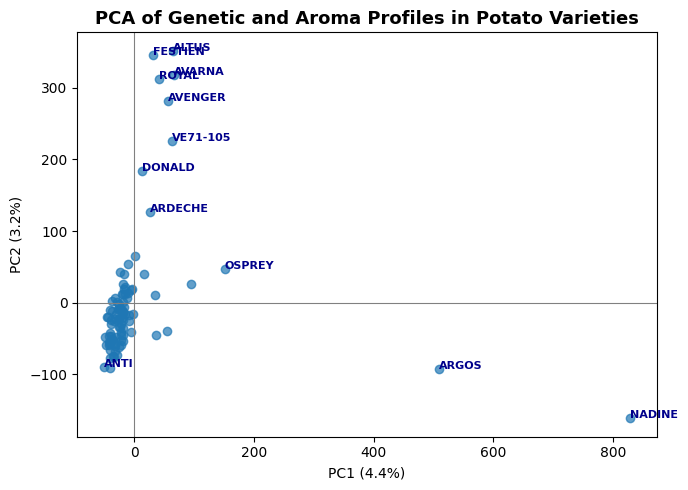

 PCA completed with 3 components.
Explained variance (first 2 PCs): [0.04357355 0.03249842]
Top 12% outliers: ['ALTUS', 'ANTI', 'ARDECHE', 'ARGOS', 'AVARNA', 'AVENGER', 'DONALD', 'FESTIEN', 'NADINE', 'OSPREY', 'ROYAL', 'VE71-105']


In [30]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_with_outliers

PCA_df, outliers, pca_model = perform_pca_with_outliers(
    merged_snp_aroma,
    n_components=3,
    outlier_percent=12,
    title="PCA of Genetic and Aroma Profiles in Potato Varieties"
)


In [31]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # --- Step 1: restore Variety column if needed ---
# if "Variety" not in merged_snp_aroma.columns:
#     merged_snp_aroma = merged_snp_aroma.reset_index().rename(
#         columns={merged_snp_aroma.index.name or "index": "Variety"}
#     )

# # --- Step 2: mark outliers ---
# merged_snp_aroma["IsOutlier"] = merged_snp_aroma["Variety"].isin(outliers)

# # Split groups
# df_out = merged_snp_aroma[merged_snp_aroma["IsOutlier"] == True]
# df_non = merged_snp_aroma[merged_snp_aroma["IsOutlier"] == False]

# # --- Step 3: define aroma columns only ---
# aroma_cols = [
#     c for c in merged_snp_aroma.columns 
#     if c not in ["Variety", "IsOutlier"] and not c.startswith("GEN__")
# ]

# # Mean of non-outliers (aroma only)
# mean_non = df_non[aroma_cols].mean()

# # --- Step 4: plot for each outlier ---
# for variety in outliers:
    
#     if variety not in merged_snp_aroma["Variety"].values:
#         print(f"Skipping {variety} (not found in dataset)")
#         continue
    
#     # Get row for that variety
#     row = merged_snp_aroma.loc[merged_snp_aroma["Variety"] == variety, aroma_cols].iloc[0]

#     # Difference vs non-outlier mean
#     diff = (row - mean_non).sort_values(ascending=False)

#     top_diff = diff.head(15)

#     # --- Plot ---
#     plt.figure(figsize=(10, 6))
#     sns.barplot(
#         x=top_diff.values,
#         y=top_diff.index,
#         palette="magma"
#     )
    
#     plt.title(f"Top Aroma Compound Differences for Outlier: {variety}", fontsize=14)
#     plt.xlabel("Difference vs Mean of Non-Outliers", fontsize=12)
#     plt.ylabel("Compound", fontsize=12)
    
#     plt.tight_layout()
#     plt.show()


# 2.PLSR on Genetic–Aroma Dataset

Top Influential Genes:
 GEN__564788    0.012132
GEN__564835    0.012132
GEN__505018    0.012132
GEN__505057    0.012132
GEN__327963    0.012132
GEN__327996    0.012132
GEN__328020    0.012132
GEN__179791    0.012132
GEN__328056    0.012132
GEN__328060    0.012132
dtype: float64

Top Influential Aroma Compounds:
 2,3-Pentanedione        0.012520
2-Methylthiazole        0.012143
Dimethyl disulfide      0.012132
Isovaleric acid         0.012132
Methional               0.011266
Acetic acid             0.010394
Propanal                0.008699
Methanethiol            0.008464
Furfural                0.008117
Octanoic acid           0.007209
Benzeneacetaldehyde     0.004725
Butanoic acid           0.003908
Ethyl hexanoate         0.003495
1-Phenylethanol         0.002991
2-Methyl-1-propanol     0.002961
Ethyl propanoate        0.002961
2,6-Dimethylpyrazine    0.002961
Ethyl acetate           0.002961
Decanal                 0.002789
Pentanal                0.002761
dtype: float64


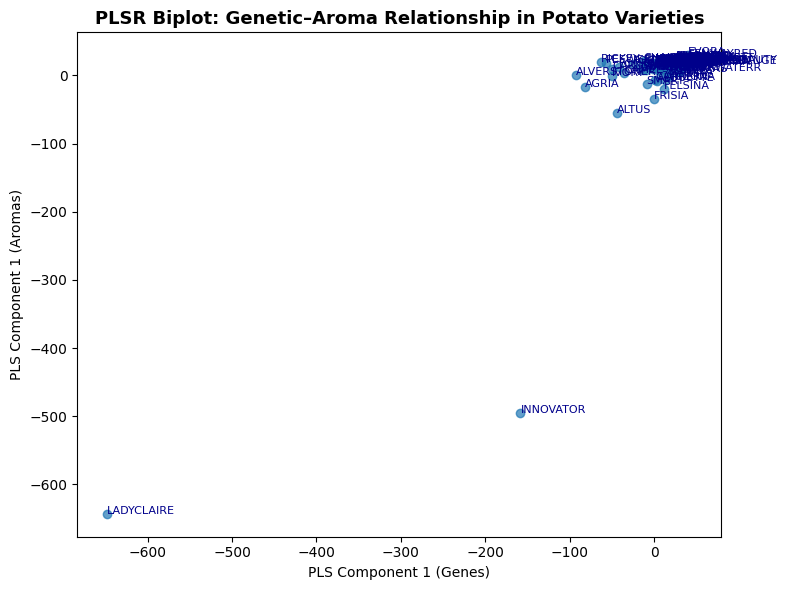


Explained variance (X, Y): (262434, 2), (47, 2)
Number of varieties analyzed: 94


In [32]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import analyze_gene_aroma_plsr
# Extract genetic and aroma parts from merged dataset
gd = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]]
A = merged_snp_aroma[[c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]]



pls_model, top_genes, top_aromas = analyze_gene_aroma_plsr(
    merged_snp_aroma,
    n_components=2,
    top_genes=10,
    top_aromas=20
)


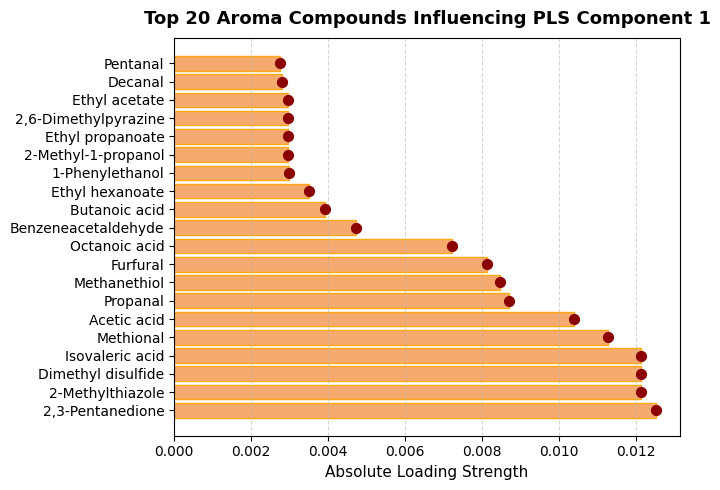

In [33]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_top_aroma_loadings_horizontal
plot_top_aroma_loadings_horizontal(top_aromas)


# 3.HCA (Ward, Euclidean) on SNP-linked aroma profiles (EDA)

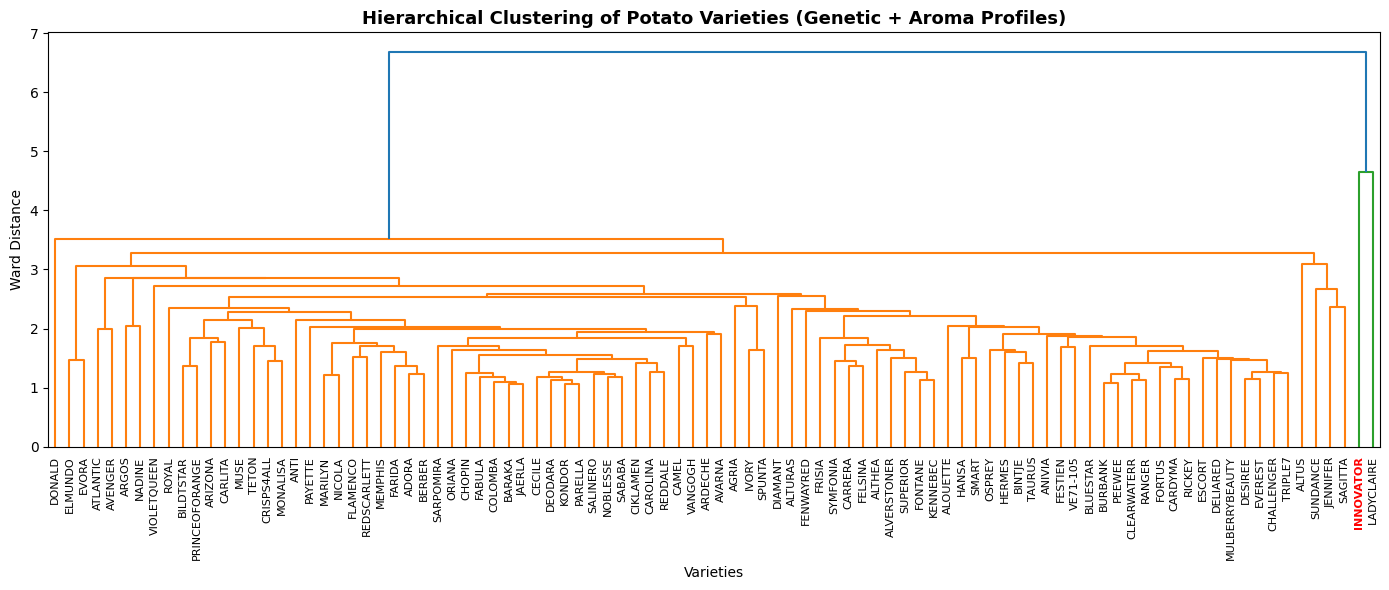

In [34]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_balanced_dendrogram_snp_aroma

Z = plot_balanced_dendrogram_snp_aroma(
    merged_snp_aroma,
    highlight_varieties=("Lady Claire", "Innovator"),
    title="Hierarchical Clustering of Potato Varieties (Genetic + Aroma Profiles)"
)


# 1. PCA of  Genetic–Sensory dataset

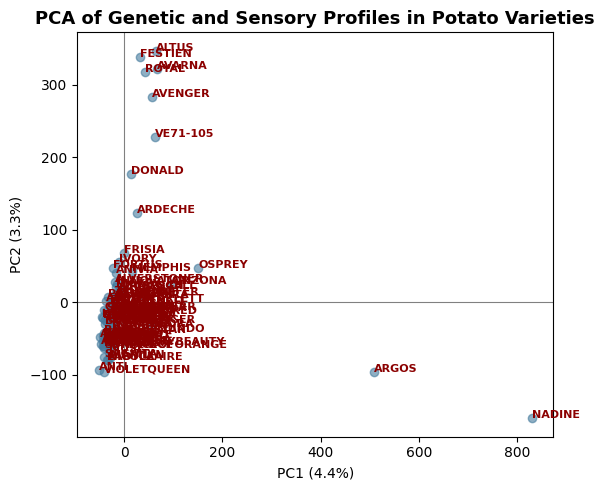

 PCA completed with 2 components.
Explained variance ratio (PC1+PC2): 7.61%
Outliers detected (94): ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONER', 'ANIVIA', 'ANTI', 'ARDECHE', 'ARGOS', 'ARIZONA', 'ATLANTIC', 'AVARNA', 'AVENGER', 'BARAKA', 'BERBER', 'BILDTSTAR', 'BINTJE', 'BLUESTAR', 'BURBANK', 'CAMEL', 'CARDYMA', 'CARLITA', 'CAROLINA', 'CARRERA', 'CECILE', 'CHALLENGER', 'CHOPIN', 'CIKLAMEN', 'CLEARWATERR', 'COLOMBA', 'CRISPS4ALL', 'DELIARED', 'DEODARA', 'DESIREE', 'DIAMANT', 'DONALD', 'ELMUNDO', 'ESCORT', 'EVEREST', 'EVORA', 'FABULA', 'FARIDA', 'FELSINA', 'FENWAYRED', 'FESTIEN', 'FLAMENCO', 'FONTANE', 'FORTUS', 'FRISIA', 'HANSA', 'HERMES', 'INNOVATOR', 'IVORY', 'JAERLA', 'JENNIFER', 'KENNEBEC', 'KONDOR', 'LADYCLAIRE', 'MARILYN', 'MEMPHIS', 'MONALISA', 'MULBERRYBEAUTY', 'MUSE', 'NADINE', 'NICOLA', 'NOBLESSE', 'ORIANA', 'OSPREY', 'PARELLA', 'PAYETTE', 'PEEWEE', 'PRINCEOFORANGE', 'RANGER', 'REDDALE', 'REDSCARLETT', 'RICKEY', 'ROYAL', 'SABABA', 'SAGITTA', 'SALI

In [35]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_gene_sensory

pca_df, pca_model, outliers = perform_pca_gene_sensory(
    merged_snp_sensory,
    n_components=2,
    outlier_threshold_pc1=4,
    outlier_threshold_pc2=3,
    title="PCA of Genetic and Sensory Profiles in Potato Varieties"
)


# 2.PLSR on Genetic–Sensory Dataset

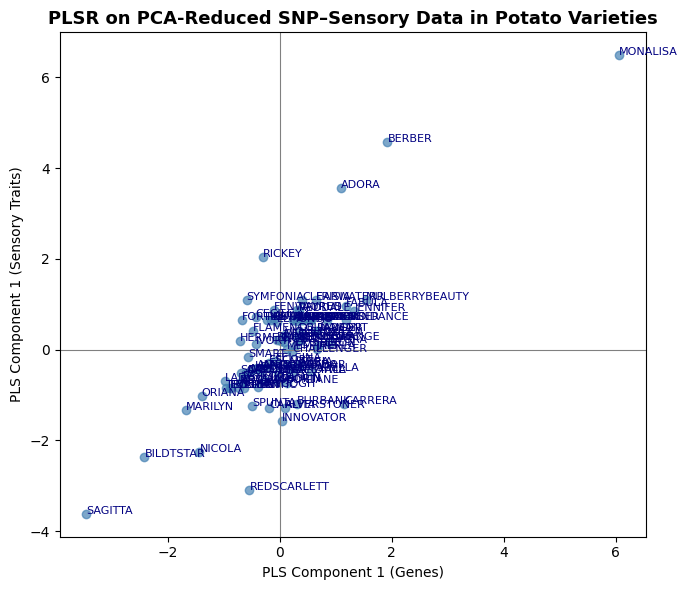

 PCA reduced SNPs to 50 components.
 PLSR computed 2 components.
Explained variance in PCA (first 3 comps): [0.04358077 0.03251347 0.02907683]
Samples plotted: 94 varieties.


In [36]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_plsr_gene_sensory


pca_model, pls_model, pls_scores_df = perform_pca_plsr_gene_sensory(
    merged_snp_sensory,
    n_pca_components=50,
    n_pls_components=2,
    title="PLSR on PCA-Reduced SNP–Sensory Data in Potato Varieties"
)


# 3.Hierarchical Clustering of Potato Varieties Based on Combined SNP and Sensory Profiles

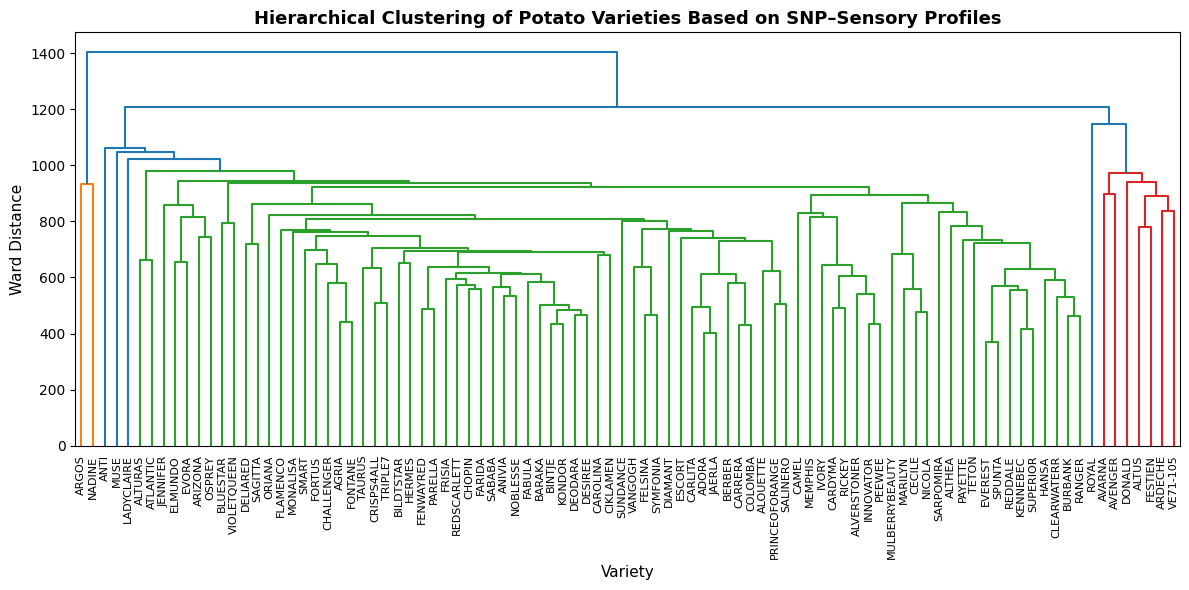

 HCA completed using ward linkage and euclidean distance.
Samples clustered: 94, Features used: 261113


In [37]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_hca_gene_sensory

Z = perform_hca_gene_sensory(
    merged_snp_sensory,
    metric="euclidean",
    method="ward",
    color_threshold_ratio=0.7,
    title="Hierarchical Clustering of Potato Varieties Based on SNP–Sensory Profiles"
)


# Feature selection

# Genome-Wide Association Study (GWAS) with FDR Correction and LD Pruning on Genetic–aroma Data

In [ ]:
import yaml
import importlib
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_gwas_for_traits



# Load Full Combined Config File
with open(config_path, "r") as f:
    config = yaml.safe_load(f)



# Select Biorep2 GWAS Output Path
gwas_gene_aroma_output = config["biorep2"]["data"]["gwas_output_gene_aroma"]



#  Run GWAS for Gene × Aroma Matrix
all_gwas_gene_aroma_df = perform_gwas_for_traits(
    merged_df=merged_snp_aroma,
    snp_prefix="GEN__",
    output_path=gwas_gene_aroma_output,
    ld_threshold=0.95,
    top_n_snps=500
)

# Confirmation
print("\n✔ GWAS for Gene–Aroma completed successfully.")
print("✔ Results saved to:", gwas_gene_aroma_output)



Detected 262434 SNP columns and 47 numeric traits.



Running GWAS per trait:   0%|          | 0/47 [00:00<?, ?it/s]


Processing trait: 1-Heptanol
  - Initial SNPs: 262434
  - After selecting top 500: 500 SNPs


Running GWAS per trait:   2%|▏         | 1/47 [09:51<7:33:44, 591.84s/it]

  - After LD pruning (r² < 0.95): 1 SNPs retained

Processing trait: 1-Nonanol
  - Initial SNPs: 262434


...

  - After selecting top 500: 500 SNPs
  - After LD pruning (r² < 0.95): 2 SNPs retained

Processing trait: 1-Octen-3-ol
  - Initial SNPs: 262434


Running GWAS per trait:   6%|▋         | 3/47 [16:58<3:35:06, 293.34s/it]

  - After selecting top 500: 500 SNPs
  - After LD pruning (r² < 0.95): 2 SNPs retained

Processing trait: 1-Phenylethanol
  - Initial SNPs: 262434
  - After selecting top 500: 500 SNPs


Running GWAS per trait:   9%|▊         | 4/47 [22:24<3:39:22, 306.11s/it]

  - After LD pruning (r² < 0.95): 28 SNPs retained

Processing trait: 2,3-Pentanedione
  - Initial SNPs: 262434


# GWas results

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\genemarker_module.py:980: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


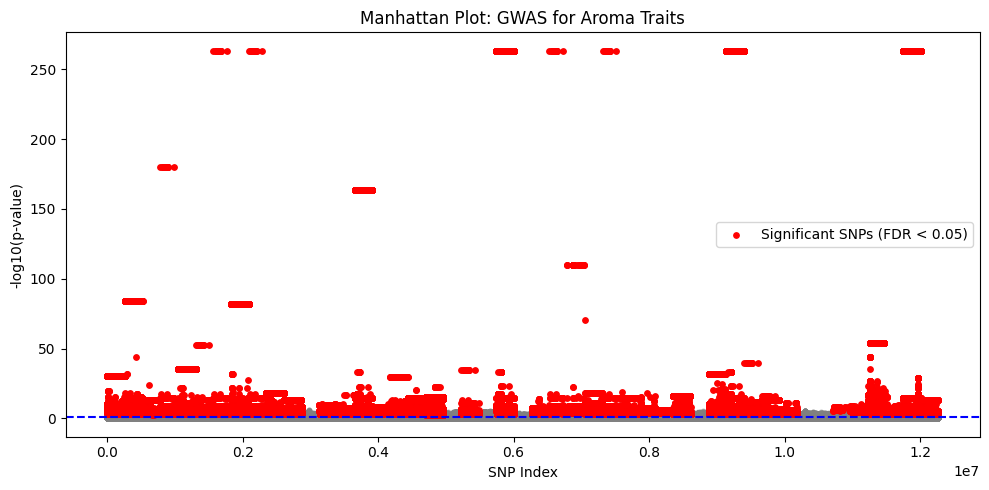

KeyboardInterrupt: 

In [ ]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_full_report


# Extract GWAS file path for Biorep2
gwas_gene_aroma_output = config["biorep2"]["data"]["gwas_output_gene_aroma"]

# Load the GWAS results
gwas_df = pd.read_csv(gwas_gene_aroma_output)

# Plot full GWAS report
plot_gwas_full_report(
    gwas_df,
    title_prefix="GWAS for Aroma Traits in Potato Varieties (Biorep2)"
)


# Multivariate Analysis of GWAS-Selected Features Using PCA, PLSR, and HCA

 Selected 82015 SNPs below FDR < 0.05


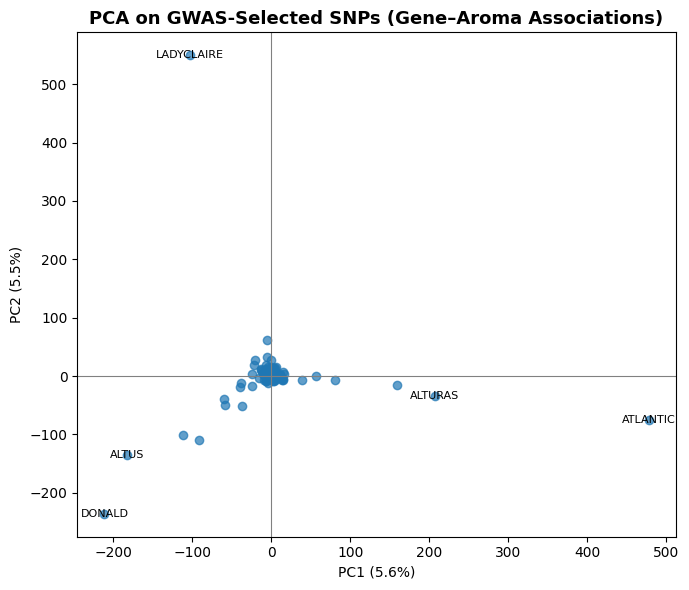

Explained variance: PC1 = 5.65%, PC2 = 5.49%


In [ ]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import pca_after_gwas_feature_selection_gene_aroma

# Run PCA after feature selection
pca_model, scores = pca_after_gwas_feature_selection_gene_aroma(
    merged_snp_aroma=merged_snp_aroma,
    gwas_df=gwas_df,
    fdr_threshold=0.05,
    n_components=2,
    title="PCA on GWAS-Selected SNPs (Gene–Aroma Associations)"
)

 Selected 82015 SNPs after GWAS feature selection (FDR < 0.05).


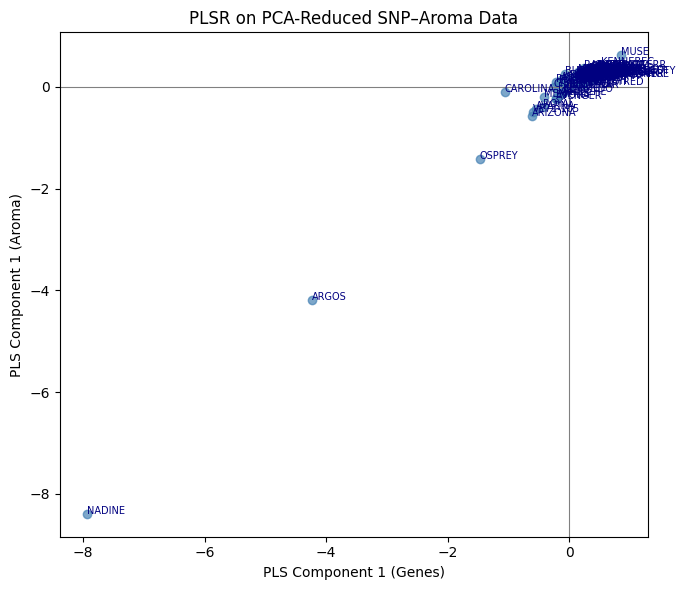

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt

def plsr_after_gwas_selection(
    merged_snp_aroma,
    gwas_file,
    fdr_col='p_fdr',
    snp_col='SNP',
    fdr_threshold=0.05,
    n_pca_components=50,
    n_pls_components=2,
    title="PLSR on PCA-Reduced SNP–Aroma Data"
):
    """
    Run PCA on GWAS-selected SNPs and perform PLSR with aroma traits.

    Parameters
    ----------
    merged_snp_aroma : pd.DataFrame
        Combined dataset of SNPs (GEN__ prefix) and aroma traits.
    gwas_file : str
        Path to the GWAS results CSV file.
    fdr_col : str, default='p_fdr'
        Column name for FDR-corrected p-values in the GWAS file.
    snp_col : str, default='SNP'
        Column name for SNP identifiers.
    fdr_threshold : float, default=0.05
        FDR threshold for selecting significant SNPs.
    n_pca_components : int, default=50
        Number of PCA components to retain.
    n_pls_components : int, default=2
        Number of PLS components.
    title : str, default="PLSR on PCA-Reduced SNP–Aroma Data"
        Title for the plot.

    Returns
    -------
    pca : PCA object
        Fitted PCA model.
    pls : PLSRegression object
        Fitted PLS model.
    X_scores, Y_scores : np.ndarray
        PLS component scores for SNP and aroma data.
    """

    # --- Load GWAS results ---
    gwas_df = pd.read_csv(gwas_file)

    # --- Select top SNPs based on FDR threshold ---
    top_snps = gwas_df.loc[gwas_df[fdr_col] < fdr_threshold, snp_col].unique().tolist()
    print(f" Selected {len(top_snps)} SNPs after GWAS feature selection (FDR < {fdr_threshold}).")

    if len(top_snps) == 0:
        print(" No SNPs passed the FDR threshold. Exiting.")
        return None, None, None, None

    # --- Prepare X (SNPs) and Y (aroma traits) ---
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    Y = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c not in top_snps]].select_dtypes(include=[np.number]).fillna(0)

    # --- Standardize ---
    X_scaled = StandardScaler().fit_transform(X)
    Y_scaled = StandardScaler().fit_transform(Y)

    # --- PCA reduction on SNPs ---
    pca = PCA(n_components=n_pca_components)
    X_reduced = pca.fit_transform(X_scaled)

    # --- PLS regression ---
    pls = PLSRegression(n_components=n_pls_components)
    pls.fit(X_reduced, Y_scaled)

    # --- Extract scores ---
    X_scores = pls.x_scores_
    Y_scores = pls.y_scores_

    # --- Plot (same as your version) ---
    plt.figure(figsize=(7, 6))
    plt.scatter(X_scores[:, 0], Y_scores[:, 0], alpha=0.7, color='steelblue')

    for i, name in enumerate(merged_snp_aroma.index):
        plt.text(X_scores[i, 0], Y_scores[i, 0], name, fontsize=7, color='navy')

    plt.axhline(0, color='gray', lw=0.8)
    plt.axvline(0, color='gray', lw=0.8)
    plt.xlabel("PLS Component 1 (Genes)")
    plt.ylabel("PLS Component 1 (Aroma)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return pca, pls, X_scores, Y_scores
pca_model, pls_model, X_scores, Y_scores = plsr_after_gwas_selection(
    merged_snp_aroma=merged_snp_aroma,
    gwas_file="C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    fdr_threshold=0.05,
    n_pca_components=50,
    n_pls_components=2
)


 Selected 82015 SNPs after GWAS feature selection (FDR < 0.05).

 PLSR model fitted successfully.

 Found 6 key varieties: ['NADINE', 'ARGOS', 'OSPREY', 'LADYCLAIRE', 'AVENGER', 'ALTUS']

 Top 10 differentiating aroma compounds for NADINE:


Butanal, 3-methyl-         1.949031
2-Propanone, 1-methoxy-    1.788382
Nonanal                    1.285026
Decanal                    0.757878
Hexanol                    0.676540
Heptanal                   0.519910
Methyl butanoate           0.472571
Hexanoic acid              0.420110
Pentanal                   0.412718
Acetophenone               0.357650
Name: NADINE, dtype: float64


 Top 10 differentiating aroma compounds for ARGOS:


Methyl butanoate           3.977030
Butanal, 3-methyl-         1.319664
Decanal                    0.865781
Octanal                    0.811681
2-Propanone, 1-methoxy-    0.769978
Hexanol                    0.676540
Tetramethylpyrazine        0.664363
Dimethyl trisulfide        0.641786
Hexanal                    0.556220
Heptanal                   0.519910
Name: ARGOS, dtype: float64


 Top 10 differentiating aroma compounds for OSPREY:


...


 Top 10 differentiating aroma compounds for AVENGER:


Benzyl alcohol             6.030643
Butanal, 3-methyl-         1.319664
Octanal                    0.804424
2-Propanone, 1-methoxy-    0.769978
Tetramethylpyrazine        0.664363
Dimethyl trisulfide        0.641786
Decanal                    0.589955
Hexanal                    0.556220
Heptanal                   0.519910
Methyl butanoate           0.472571
Name: AVENGER, dtype: float64


 Top 10 differentiating aroma compounds for ALTUS:


2,4-Decadienal             8.617151
Ethyl pentanoate           6.639365
Propanal                   4.842913
Isoamyl acetate            3.308447
Heptanal                   1.504430
Methyl butanoate           1.419851
2-Propanone, 1-methoxy-    1.169626
Benzeneacetaldehyde        1.100180
Octanal                    0.892242
Butanal, 3-methyl-         0.711710
Name: ALTUS, dtype: float64

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


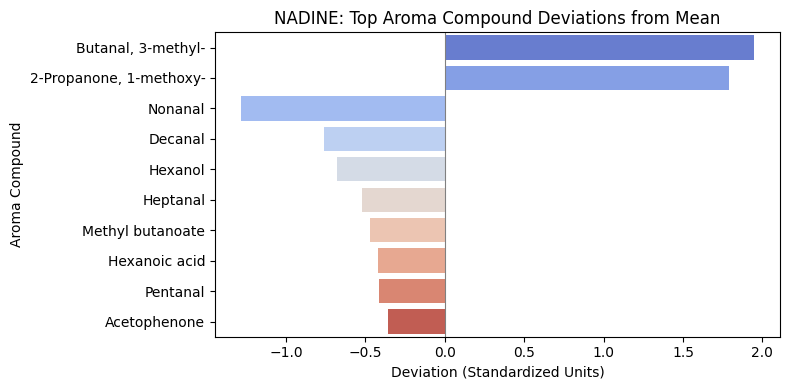

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


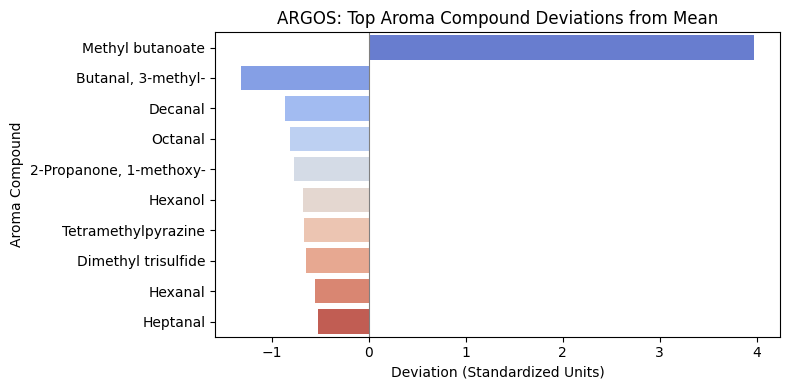

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


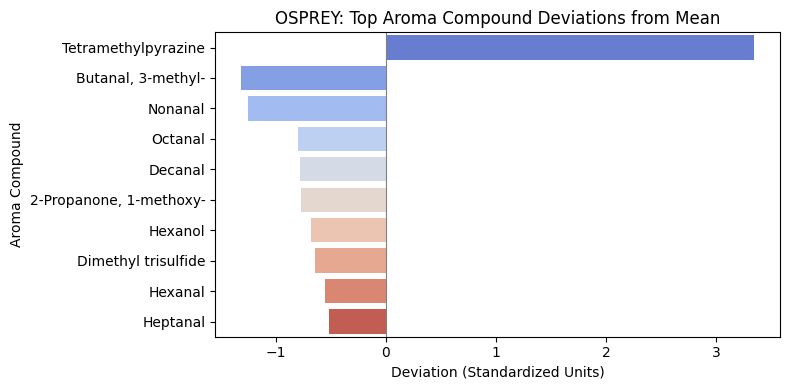

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


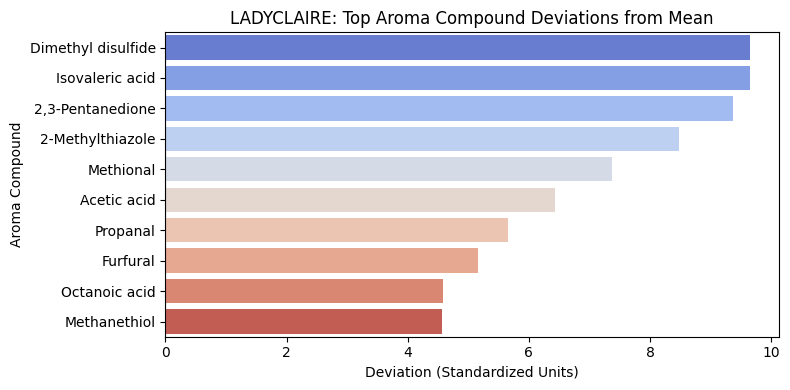

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


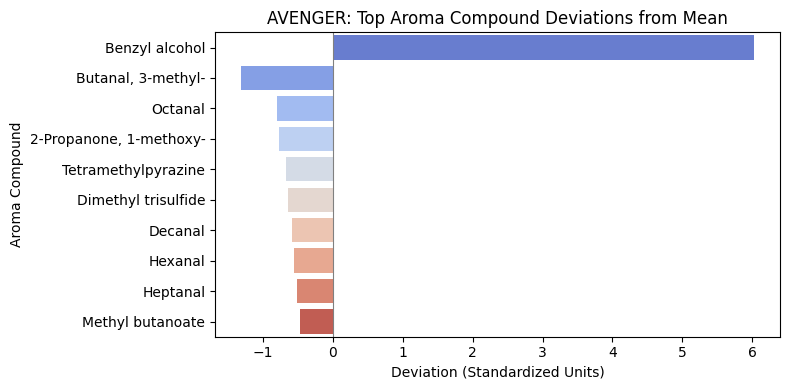

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


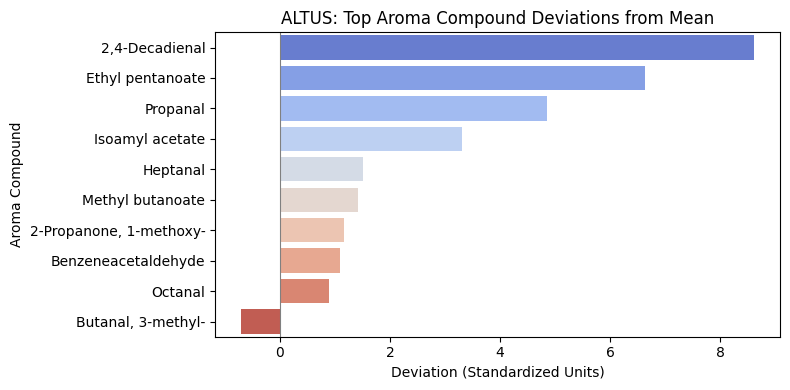


 Results saved as: key_variety_top_aroma_compounds.csv


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import analyze_key_variety_aroma_profiles

summary_df = analyze_key_variety_aroma_profiles(
    merged_snp_aroma=merged_snp_aroma,
    gwas_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    key_varieties=["NADINE", "ARGOS", "OSPREY",'Lady Claire','Avenger','Altus'],
    top_n_compounds=10,
    save_path="key_variety_top_aroma_compounds.csv"
)


# Genome-Wide Association Study (GWAS) with FDR Correction and LD Pruning on Genetic–Sensory Data

In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_gwas_for_sensory_pcs

# --- Load configuration file ---
with open("config_biorep2.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Extract GWAS output path from config ---
gwas_output_sensory = config["data"]["gwas_output_sensory"]

# --- Run GWAS using parameters from config ---
all_gwas_df_sensory = run_gwas_for_sensory_pcs(
    merged_snp_sensory=merged_snp_sensory,
    snp_prefix="GEN__",
    traits=["PC1", "PC2", "PC3"],
    ld_threshold=0.95,
    output_path=gwas_output_sensory
)

print(f"\n GWAS results for sensory PCs saved to:\n{gwas_output_sensory}")



🔹 Running GWAS for PC1...

🔹 Running GWAS for PC2...

🔹 Running GWAS for PC3...

 All GWAS results saved to C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/gwas_sensory_PCs.csv

 GWAS results for sensory PCs saved to:
C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/gwas_sensory_PCs.csv


# PCA Outlier Detection on GWAS-Selected SNPs

 Significant SNPs found: 341


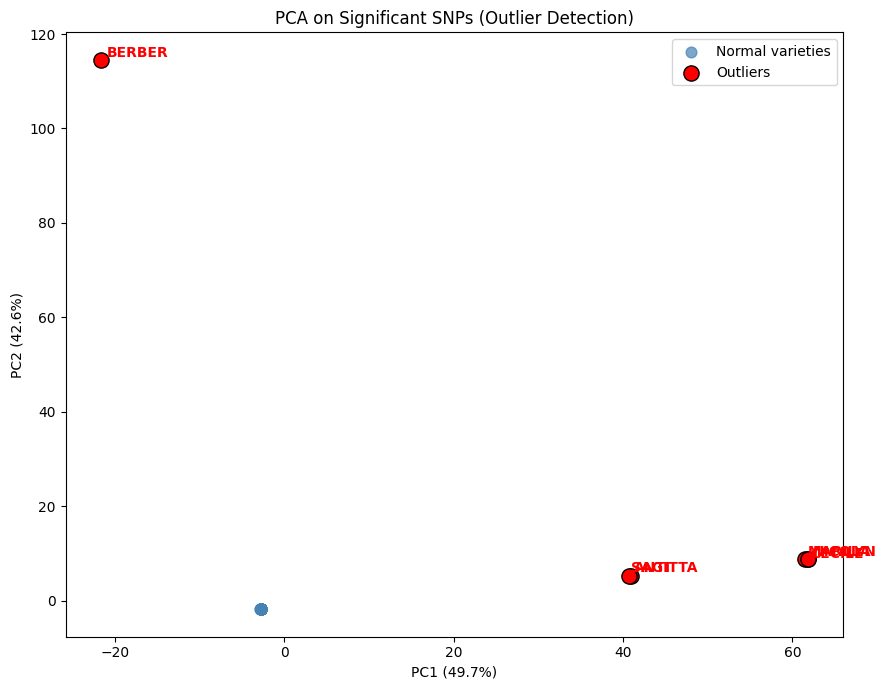

Detected PCA Outliers: ['ANTI', 'BERBER', 'CECILE', 'MARILYN', 'NICOLA', 'SAGITTA']


(94, 262437)

In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  analyze_gwas_snps_pca


with open("config_biorep2.yaml", "r") as f:
    config = yaml.safe_load(f)

results_pca = analyze_gwas_snps_pca(
    gwas_path=gwas_output_sensory,  # pass the file path, not the DataFrame
    merged_snp_sensory=merged_snp_sensory
)


print("Detected PCA Outliers:", results_pca["pca_outliers"])


merged_snp_sensory.shape

# Sensory Profile Comparison of Outlier Varieties

In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import reconstruct_sensory_traits_from_pca, plot_sensory_profiles_of_pca_outliers


sensory_reconstructed_df = reconstruct_sensory_traits_from_pca(
    projection_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep2\results\sensory_pca_projection_knn.csv",
    loadings_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep2\results\sensory_pca_loadings.csv",
    save_path=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep2\results\reconstructed_sensory.csv',  
    n_components=3
)


# plot_sensory_profiles_of_pca_outliers(results_pca, sensory_reconstructed_df)

 Reconstructed sensory traits using 3 PCs:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits → C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep2\results\reconstructed_sensory.csv


# Manhattan-Like Visualization of Sensory GWAS Results

Columns: ['SNP', 'p_value', 'p_fdr', 'Trait']


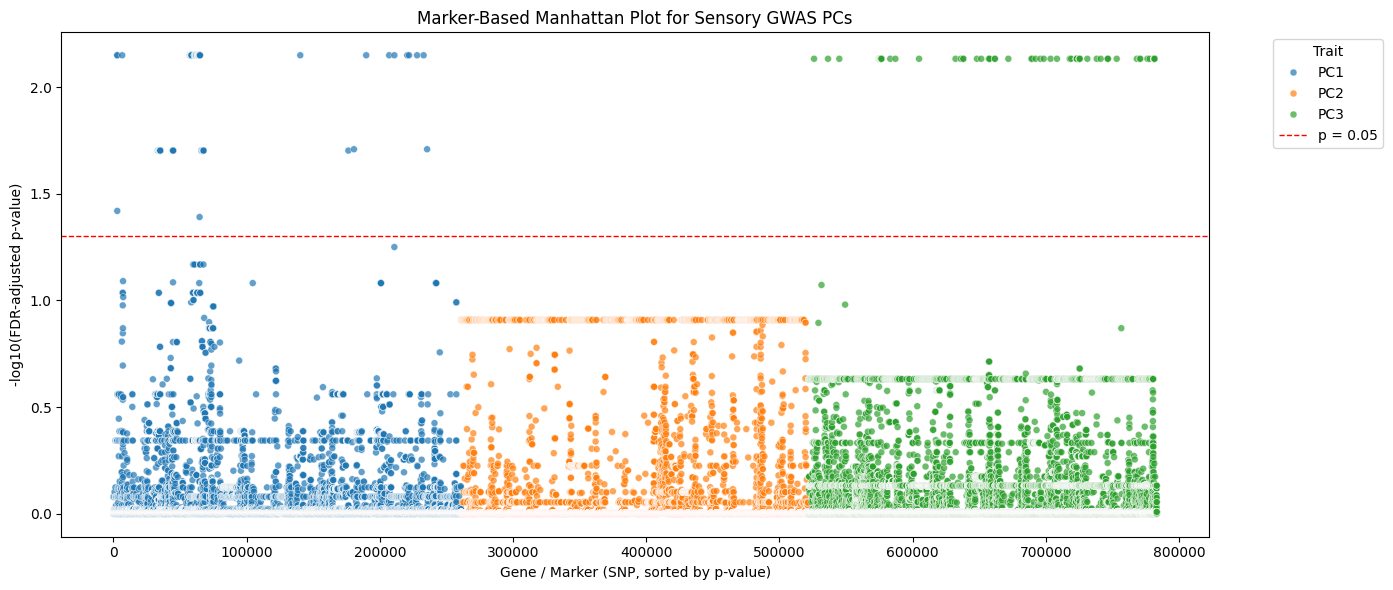

Min raw p-value: 1.1861024909502669e-06
Min FDR-adjusted p-value: 0.0070997225677086
Trait
PC1    261110
PC2    261110
PC3    261110
Name: count, dtype: int64
435 SNPs are FDR-significant


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_manhattan_like_gwas

# plot_manhattan_like_gwas(
#      "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/gwas_sensory_PCs.csv"
# )


# with open("config.yaml", "r") as f:
#     config = yaml.safe_load(f)

# # Get GWAS file path
# gwas_gene_aroma_output = config["data"]["gwas_output_gene_aroma"]

# #  Read file into DataFrame
# gwas_df = pd.read_csv(gwas_gene_aroma_output)

# # Call plotting function with the DataFrame
# plot_gwas_full_report(
#     gwas_df,
#     title_prefix="GWAS for Aroma Traits in Potato Varieties"
# )


# --- Load GWAS results ---
file_path = "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/gwas_sensory_PCs.csv"
all_gwas_sensory = pd.read_csv(file_path)

# Check columns
print("Columns:", all_gwas_sensory.columns.tolist())

# --- Manhattan-like plot without chromosome info ---
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=all_gwas_sensory.sort_values("p_fdr"),
    x=range(len(all_gwas_sensory)),
    y=-np.log10(all_gwas_sensory["p_fdr"]),
    hue="Trait",
    palette="tab10",
    s=25,
    alpha=0.7
)

# Significance threshold line (p = 0.05)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p = 0.05")

# Titles and labels
plt.title("Marker-Based Manhattan Plot for Sensory GWAS PCs")
plt.xlabel("Gene / Marker (SNP, sorted by p-value)")
plt.ylabel("-log10(FDR-adjusted p-value)")
plt.legend(title="Trait", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Summary stats
print("Min raw p-value:", all_gwas_sensory["p_value"].min())
print("Min FDR-adjusted p-value:", all_gwas_sensory["p_fdr"].min())
print(all_gwas_sensory["Trait"].value_counts())
print((all_gwas_sensory["p_fdr"] < 0.1).sum(), "SNPs are FDR-significant")


# Volcano Plot Visualization of GWAS Results for Sensory Principal Components

 'effect_size' column not found — generated random values for visualization.


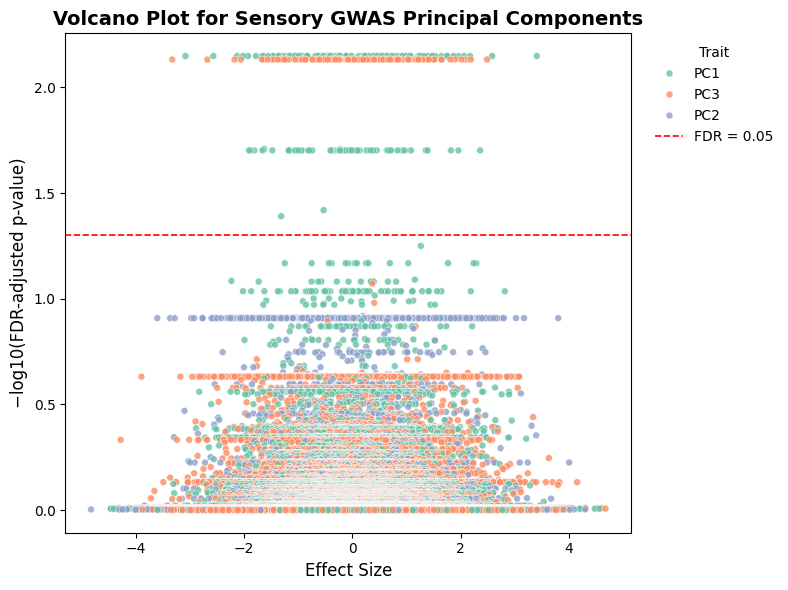

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_volcano

# --- Import and call the function ---
plot_gwas_volcano(
     "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/gwas_sensory_PCs.csv",
    fdr_threshold=0.05
)



# QQ Plot for GWAS p-Value Distribution (Sensory Principal Components)

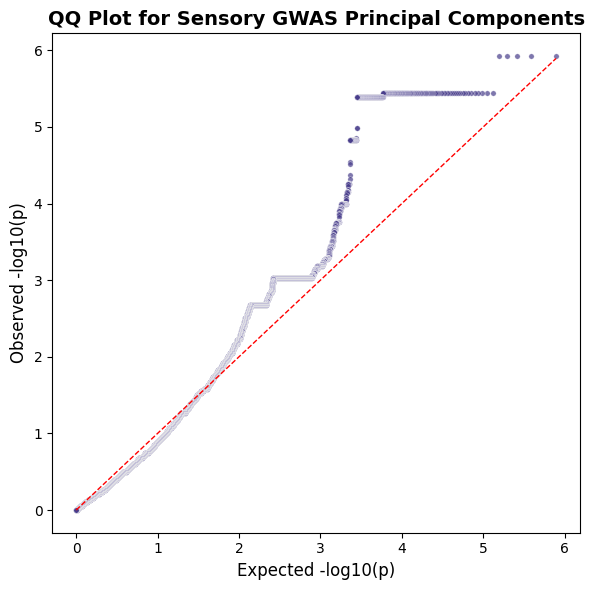

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_qq
import pandas as pd
all_gwas_df_sensory= pd.read_csv('C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/gwas_sensory_PCs.csv')
plot_gwas_qq(all_gwas_df_sensory, pval_col="p_value")


# Comparison of Linear and Regularized Regression Models for GWAS Trait Prediction


[Linear Models — unseen] Trait: 1-Heptanol

[Linear Models — unseen] Trait: 1-Nonanol

[Linear Models — unseen] Trait: 1-Octen-3-ol

[Linear Models — unseen] Trait: 1-Phenylethanol

[Linear Models — unseen] Trait: 2,3-Pentanedione

[Linear Models — unseen] Trait: 2,4-Decadienal

[Linear Models — unseen] Trait: 2,6-Dimethylpyrazine

[Linear Models — unseen] Trait: 2-Isopropyl-3-methoxypyrazine

[Linear Models — unseen] Trait: 2-Methyl-1-propanol

[Linear Models — unseen] Trait: 2-Methylthiazole

[Linear Models — unseen] Trait: 2-Nonanone

[Linear Models — unseen] Trait: 2-Propanone, 1-methoxy-

[Linear Models — unseen] Trait: 3-Heptanone

[Linear Models — unseen] Trait: 3-Octanone

[Linear Models — unseen] Trait: Acetic acid

[Linear Models — unseen] Trait: Acetophenone

[Linear Models — unseen] Trait: Benzaldehyde

[Linear Models — unseen] Trait: Benzeneacetaldehyde

[Linear Models — unseen] Trait: Benzyl alcohol

[Linear Models — unseen] Trait: Butanal, 3-methyl-

[Linear Models — un

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\linear_plot_unseen.png


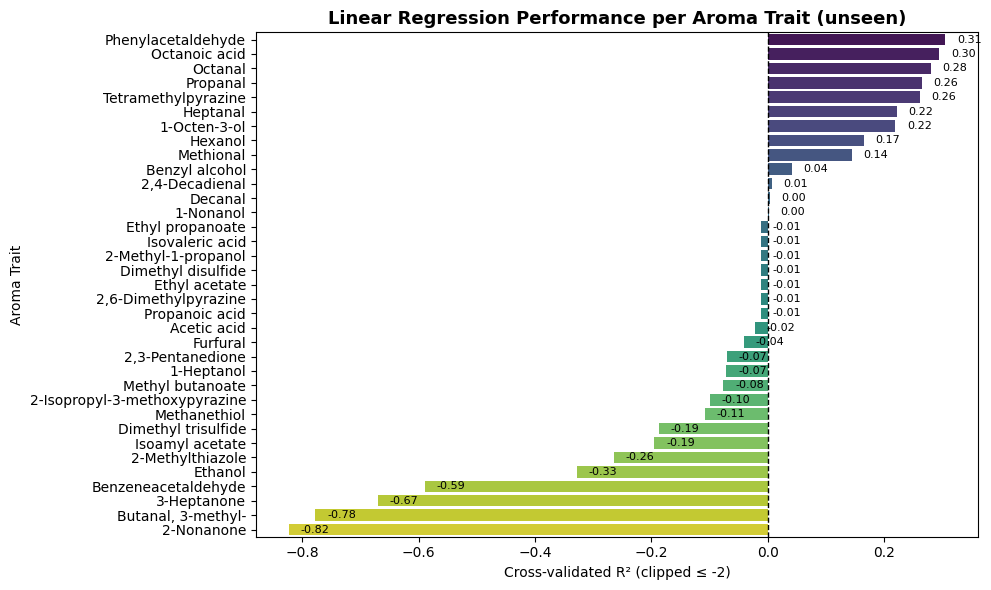

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\ridge_plot_unseen.png


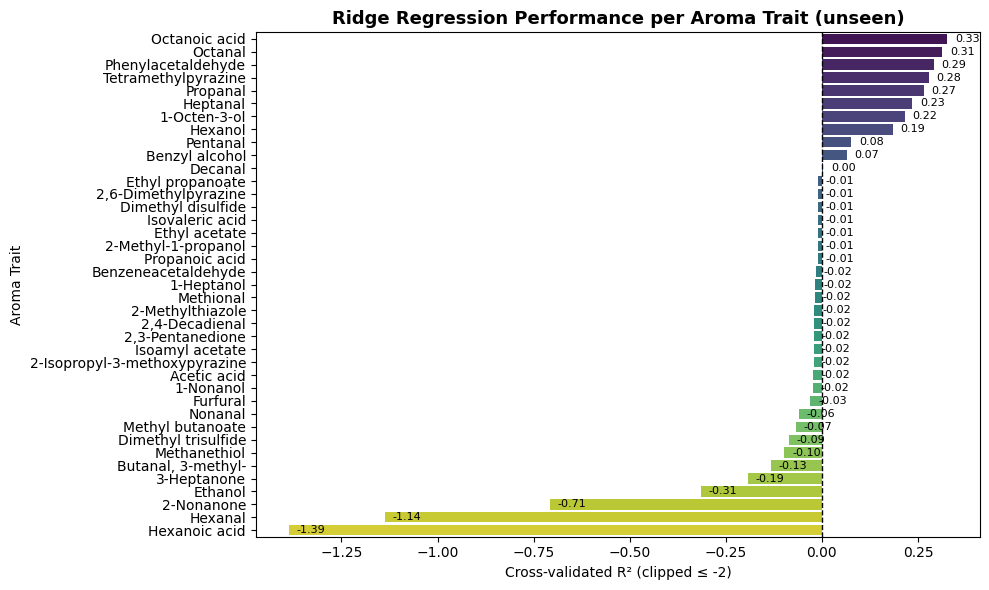

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\lasso_plot_unseen.png


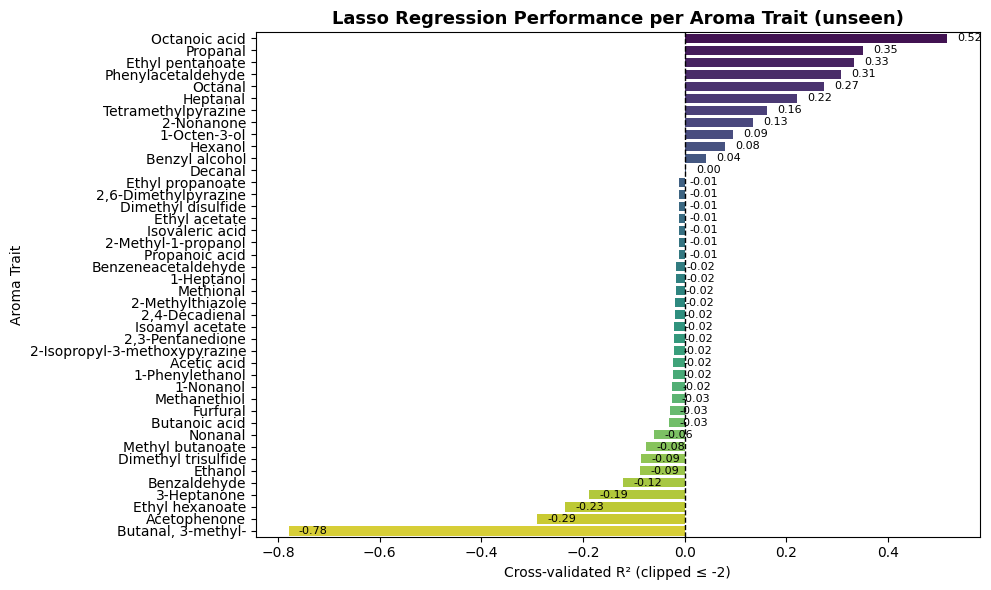

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\elasticnet_plot_unseen.png


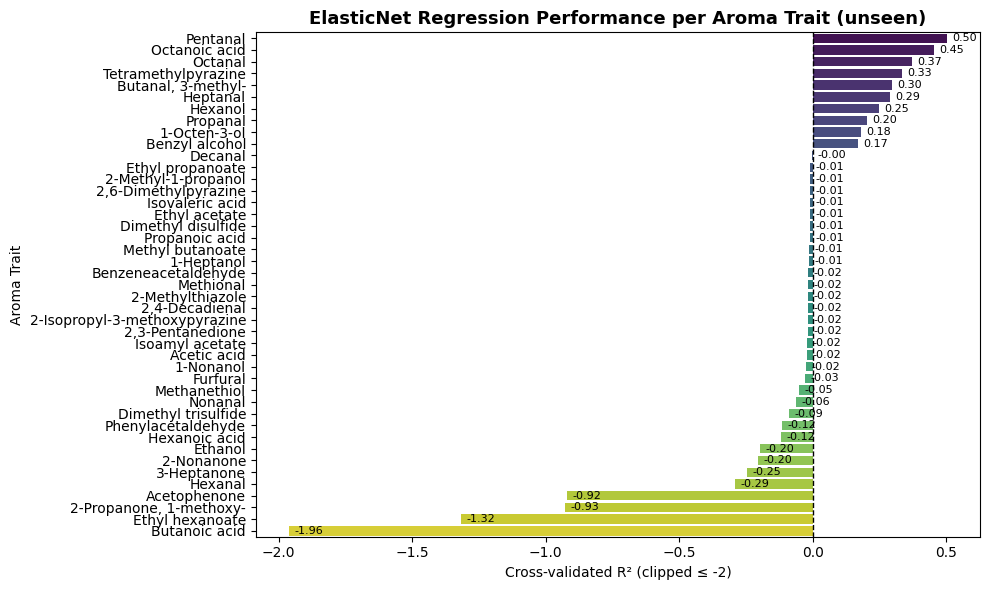

,Trait,Model,n_SNPs,CV_Best_R2,R2,MSE,MAE
0,1-Heptanol,Linear,1,-0.070906,0.940203,1.772004e+09,14258.926172
1,1-Heptanol,Ridge,1,-0.017078,0.940099,1.775091e+09,14607.810903
2,1-Heptanol,Lasso,1,-0.017527,0.940203,1.772004e+09,14258.985742
3,1-Heptanol,ElasticNet,1,-0.014394,0.924207,2.246024e+09,18582.088954
4,1-Nonanol,Linear,2,0.002121,0.592055,4.787562e+09,33444.842452
...,...,...,...,...,...,...,...
183,Propanoic acid,ElasticNet,1,-0.011111,0.982985,7.673779e+06,568.392412
184,Tetramethylpyrazine,Linear,14,0.261138,0.579160,2.313707e+10,111948.694441
185,Tetramethylpyrazine,Ridge,14,0.278293,0.579093,2.314074e+10,112091.790870
186,Tetramethylpyrazine,Lasso,14,0.161255,0.579160,2.313707e+10,111948.731118


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_linear_models_gene_aroma


run_linear_models_gene_aroma(
    gwas_file= r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    snp_df=merged_snp_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2",
    tag="unseen"
)



# Linear model after outlier removal

Detected 2 outliers (Z > 3): ['ARGOS', 'NADINE']
Remaining samples after outlier removal: 92
Remaining samples after outlier removal: 92

[Linear Models — outlier removed] Trait: 1-Heptanol

[Linear Models — outlier removed] Trait: 1-Nonanol

[Linear Models — outlier removed] Trait: 1-Octen-3-ol

[Linear Models — outlier removed] Trait: 1-Phenylethanol

[Linear Models — outlier removed] Trait: 2,3-Pentanedione

[Linear Models — outlier removed] Trait: 2,4-Decadienal

[Linear Models — outlier removed] Trait: 2,6-Dimethylpyrazine

[Linear Models — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[Linear Models — outlier removed] Trait: 2-Methyl-1-propanol

[Linear Models — outlier removed] Trait: 2-Methylthiazole

[Linear Models — outlier removed] Trait: 2-Nonanone

[Linear Models — outlier removed] Trait: 2-Propanone, 1-methoxy-

[Linear Models — outlier removed] Trait: 3-Heptanone

[Linear Models — outlier removed] Trait: 3-Octanone

[Linear Models — outlier removed] Trait: Aceti

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\linear_plot_outlier_removed.png


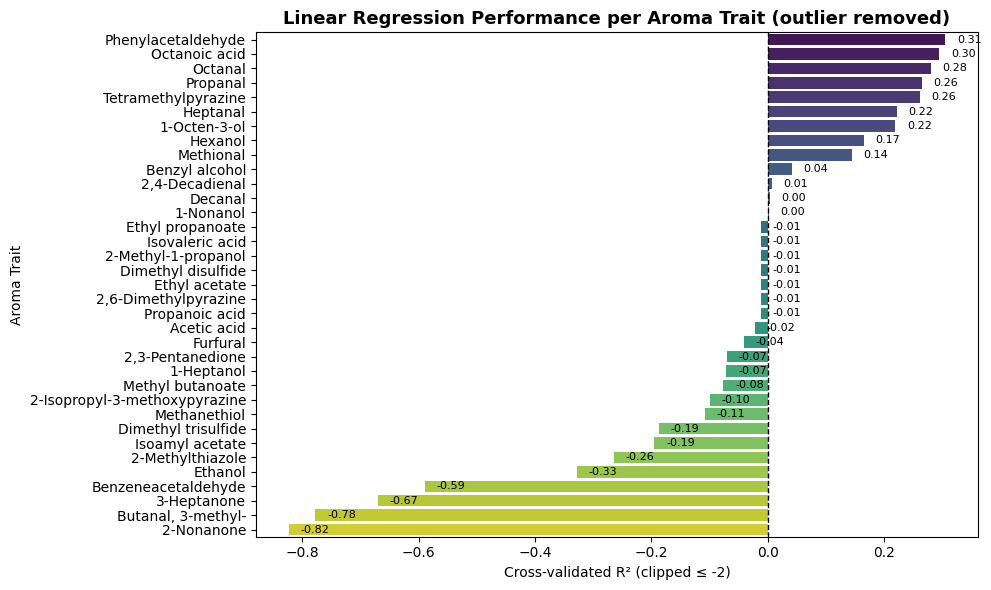

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\ridge_plot_outlier_removed.png


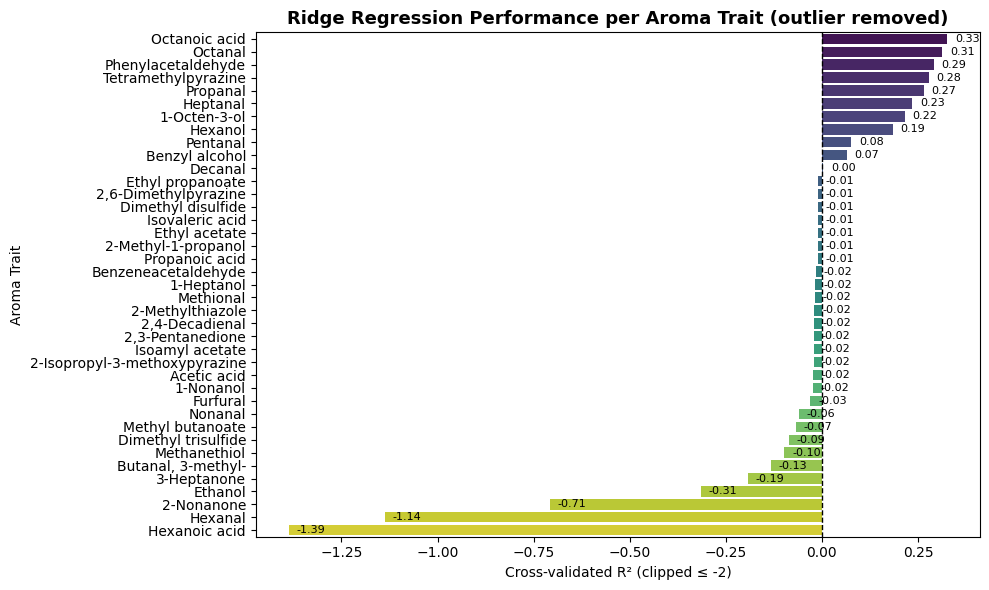

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\lasso_plot_outlier_removed.png


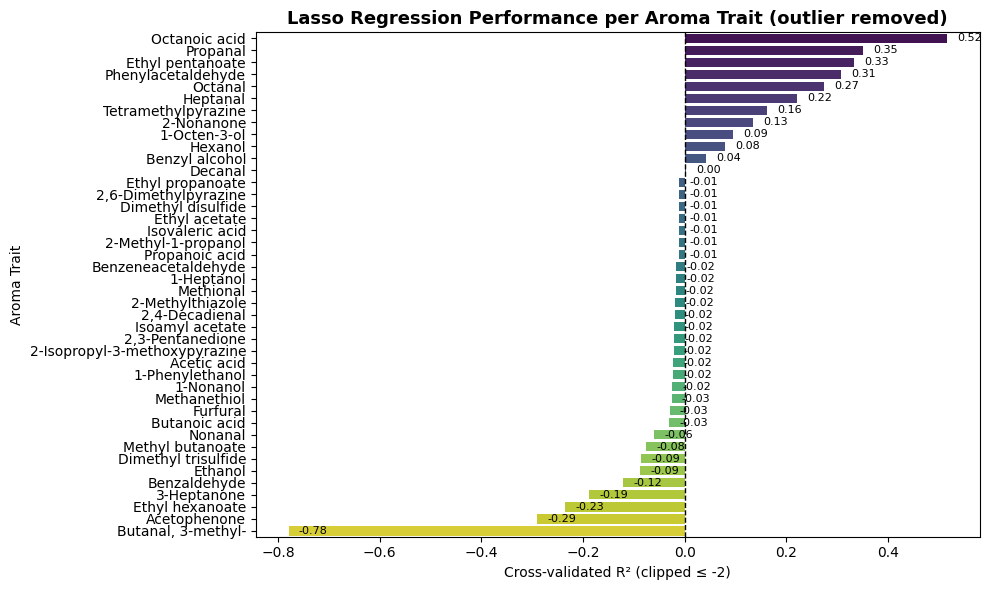

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:1857: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\elasticnet_plot_outlier_removed.png


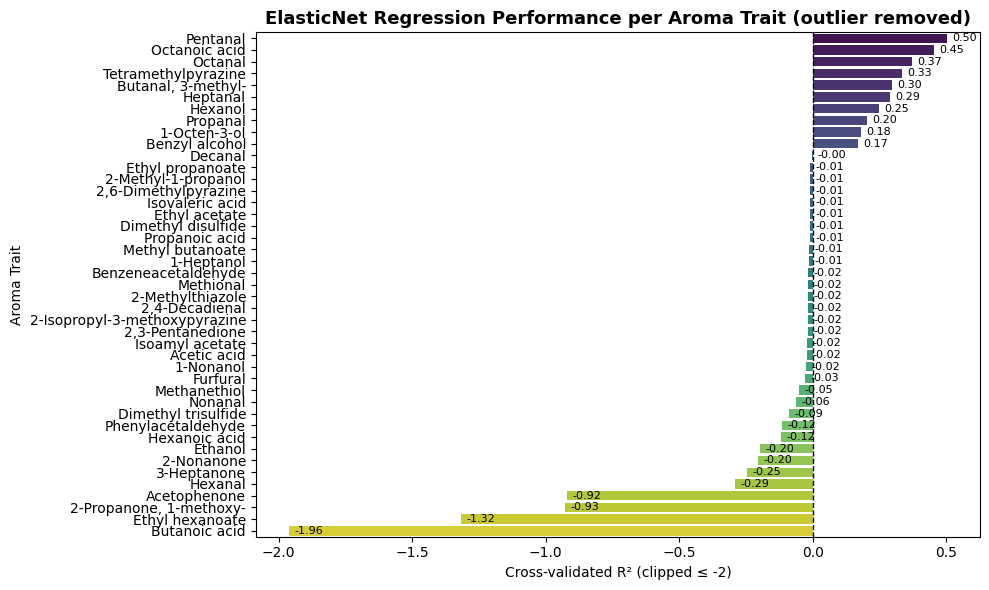

,Trait,Model,n_SNPs,CV_Best_R2,R2,MSE,MAE
0,1-Heptanol,Linear,1,-0.070906,0.940203,1.772004e+09,14258.926172
1,1-Heptanol,Ridge,1,-0.017078,0.940099,1.775091e+09,14607.810903
2,1-Heptanol,Lasso,1,-0.017527,0.940203,1.772004e+09,14258.985742
3,1-Heptanol,ElasticNet,1,-0.014394,0.924207,2.246024e+09,18582.088954
4,1-Nonanol,Linear,2,0.002121,0.592055,4.787562e+09,33444.842452
...,...,...,...,...,...,...,...
183,Propanoic acid,ElasticNet,1,-0.011111,0.982985,7.673779e+06,568.392412
184,Tetramethylpyrazine,Linear,14,0.261138,0.579160,2.313707e+10,111948.694441
185,Tetramethylpyrazine,Ridge,14,0.278293,0.579093,2.314074e+10,112091.790870
186,Tetramethylpyrazine,Lasso,14,0.161255,0.579160,2.313707e+10,111948.731118


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import detect_outliers_aroma_genefrom_plsr , run_linear_models_gene_aroma

# Detect outliers
outlier_samples = detect_outliers_aroma_genefrom_plsr(
    X_scores, Y_scores, merged_snp_aroma.index, z_threshold=3
)

cleaned_data_gene_aroma = merged_snp_aroma.drop(index=outlier_samples)
print(f"Remaining samples after outlier removal: {len(cleaned_data_gene_aroma)}")


# Remove them
cleaned_data_gene_aroma = merged_snp_aroma.drop(index=outlier_samples)
print(f"Remaining samples after outlier removal: {len(cleaned_data_gene_aroma)}")



run_linear_models_gene_aroma(
    gwas_file= r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    top_n_snps=500,
    snp_df=merged_snp_aroma,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2",
    tag="outlier removed"
)




# Nonlinear Modeling of GWAS-Selected SNPs for Aroma Trait Prediction


[Nonlinear Models — full] Trait: 1-Heptanol

[Nonlinear Models — full] Trait: 1-Nonanol

[Nonlinear Models — full] Trait: 1-Octen-3-ol

[Nonlinear Models — full] Trait: 1-Phenylethanol

[Nonlinear Models — full] Trait: 2,3-Pentanedione

[Nonlinear Models — full] Trait: 2,4-Decadienal

[Nonlinear Models — full] Trait: 2,6-Dimethylpyrazine

[Nonlinear Models — full] Trait: 2-Isopropyl-3-methoxypyrazine

[Nonlinear Models — full] Trait: 2-Methyl-1-propanol

[Nonlinear Models — full] Trait: 2-Methylthiazole

[Nonlinear Models — full] Trait: 2-Nonanone

[Nonlinear Models — full] Trait: 2-Propanone, 1-methoxy-

[Nonlinear Models — full] Trait: 3-Heptanone

[Nonlinear Models — full] Trait: 3-Octanone

[Nonlinear Models — full] Trait: Acetic acid

[Nonlinear Models — full] Trait: Acetophenone

[Nonlinear Models — full] Trait: Benzaldehyde

[Nonlinear Models — full] Trait: Benzeneacetaldehyde

[Nonlinear Models — full] Trait: Benzyl alcohol

[Nonlinear Models — full] Trait: Butanal, 3-methyl-


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\svr_plot_full.png


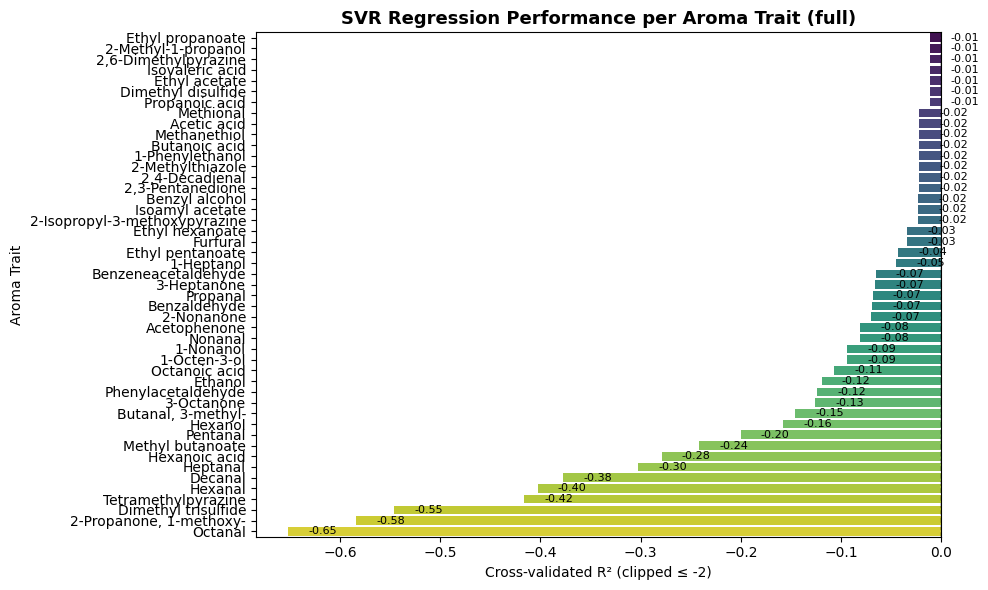

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\randomforest_plot_full.png


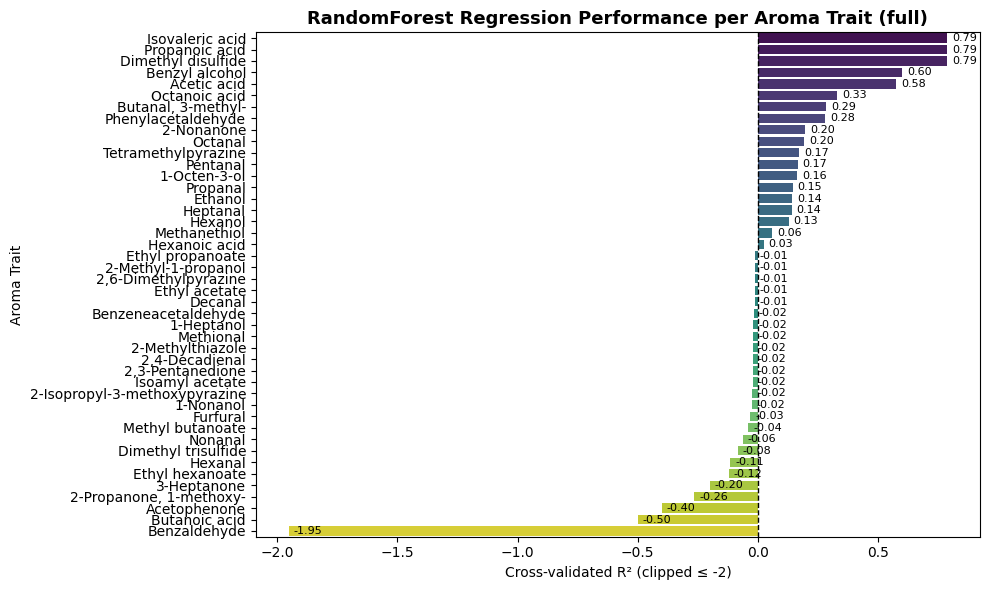

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\xgboost_plot_full.png


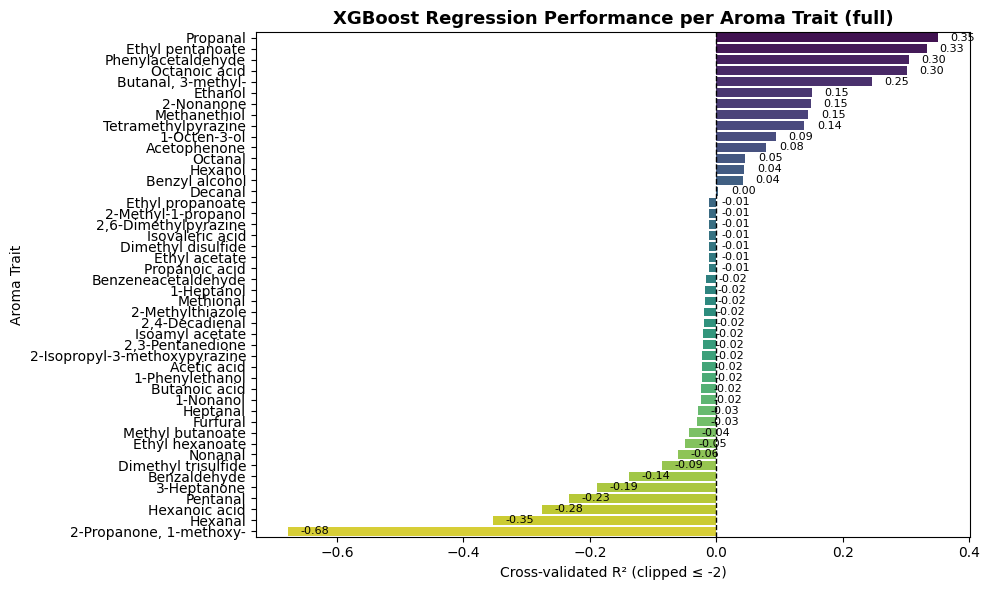

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_gene_aroma


results_nonlinear_outlier_removed = run_nonlinear_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    snp_df=merged_snp_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2",
    tag="full"
)


# Nonlinear Modeling After Outlier Removal


[Nonlinear Models — outlier removed] Trait: 1-Heptanol

[Nonlinear Models — outlier removed] Trait: 1-Nonanol

[Nonlinear Models — outlier removed] Trait: 1-Octen-3-ol

[Nonlinear Models — outlier removed] Trait: 1-Phenylethanol

[Nonlinear Models — outlier removed] Trait: 2,3-Pentanedione

[Nonlinear Models — outlier removed] Trait: 2,4-Decadienal

[Nonlinear Models — outlier removed] Trait: 2,6-Dimethylpyrazine

[Nonlinear Models — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[Nonlinear Models — outlier removed] Trait: 2-Methyl-1-propanol

[Nonlinear Models — outlier removed] Trait: 2-Methylthiazole

[Nonlinear Models — outlier removed] Trait: 2-Nonanone

[Nonlinear Models — outlier removed] Trait: 2-Propanone, 1-methoxy-

[Nonlinear Models — outlier removed] Trait: 3-Heptanone

[Nonlinear Models — outlier removed] Trait: 3-Octanone

[Nonlinear Models — outlier removed] Trait: Acetic acid

[Nonlinear Models — outlier removed] Trait: Acetophenone

[Nonlinear Models — outlie

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\svr_plot_outlier_removed.png


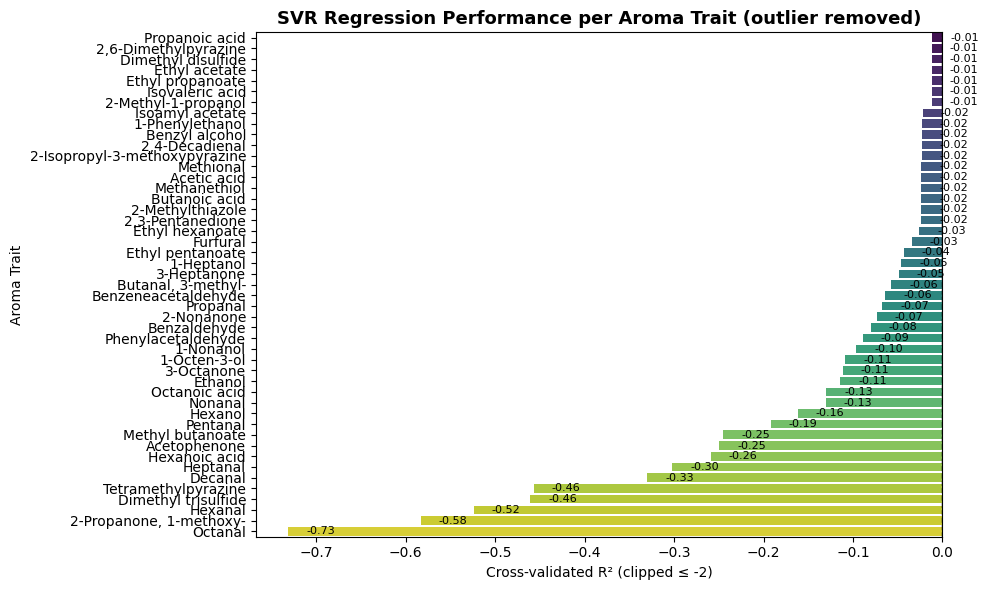

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\randomforest_plot_outlier_removed.png


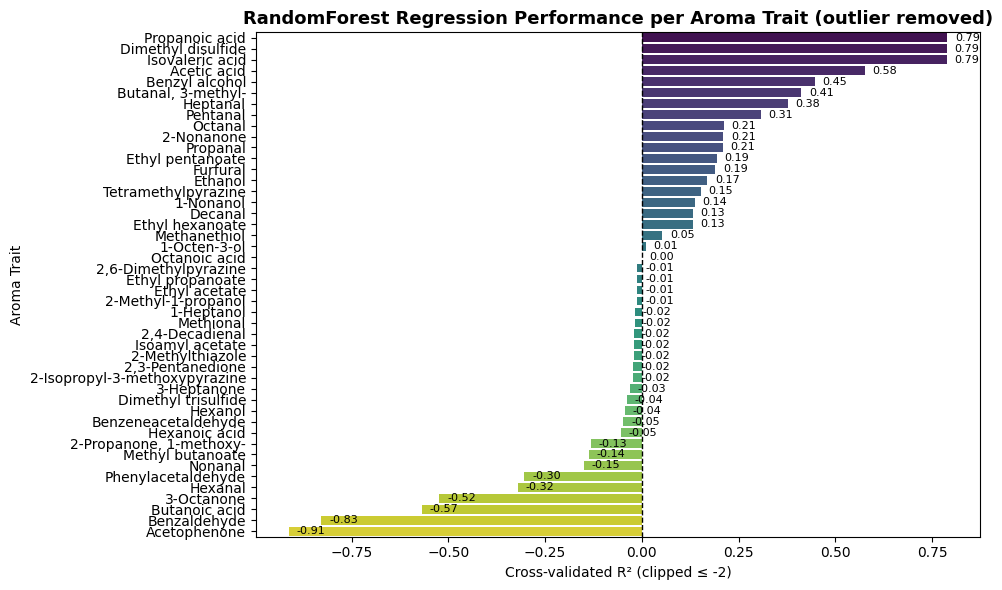

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\xgboost_plot_outlier_removed.png


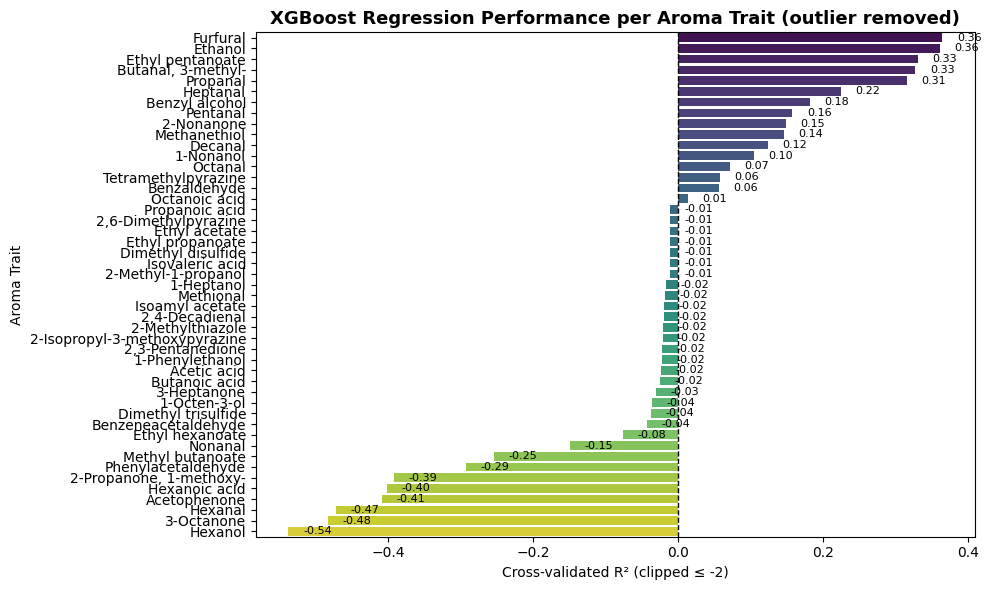

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_gene_aroma



results_nonlinear_outlier_removed = run_nonlinear_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2",
    tag="outlier removed"
)

# Cross-Validated Kernel Ridge Regression Framework for GWAS Trait Modeling”


 Running KRR with top_n_snps = 5000

[KRR — top5000] Trait: 1-Heptanol

[KRR — top5000] Trait: 1-Nonanol

[KRR — top5000] Trait: 1-Octen-3-ol

[KRR — top5000] Trait: 1-Phenylethanol

[KRR — top5000] Trait: 2,3-Pentanedione

[KRR — top5000] Trait: 2,4-Decadienal

[KRR — top5000] Trait: 2,6-Dimethylpyrazine

[KRR — top5000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top5000] Trait: 2-Methyl-1-propanol

[KRR — top5000] Trait: 2-Methylthiazole

[KRR — top5000] Trait: 2-Nonanone

[KRR — top5000] Trait: 2-Propanone, 1-methoxy-

[KRR — top5000] Trait: 3-Heptanone

[KRR — top5000] Trait: 3-Octanone

[KRR — top5000] Trait: Acetic acid

[KRR — top5000] Trait: Acetophenone

[KRR — top5000] Trait: Benzaldehyde

[KRR — top5000] Trait: Benzeneacetaldehyde

[KRR — top5000] Trait: Benzyl alcohol

[KRR — top5000] Trait: Butanal, 3-methyl-

[KRR — top5000] Trait: Butanoic acid

[KRR — top5000] Trait: Decanal

[KRR — top5000] Trait: Dimethyl disulfide

[KRR — top5000] Trait: Dimethyl trisulfide

[KRR 

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2012: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\krr_models_plot_top5000.png


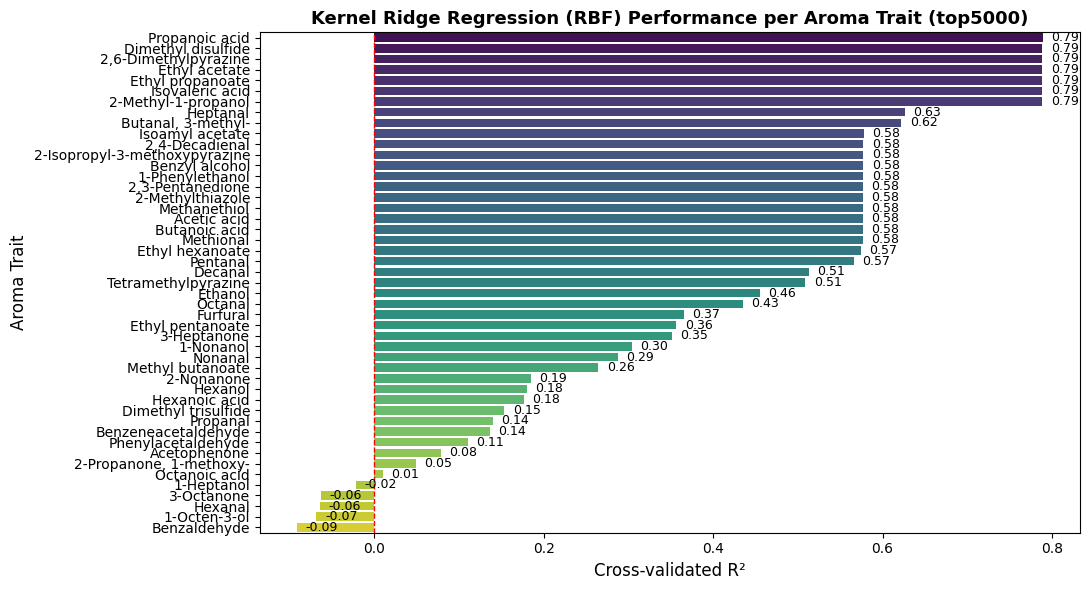

→ Mean CV R² for top_n_snps = 5000: 0.4044


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_krr_models_gene_aroma

snps_to_test = [5000]
mean_r2_results = {}

for n in snps_to_test:
    print(f"\n Running KRR with top_n_snps = {n}")
    results_df, _ = run_krr_models_gene_aroma(
        gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
        snp_df=cleaned_data_gene_aroma,
        top_n_snps=n,
        prune_threshold=0.95,
        save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2",
        tag=f"top{n}"
    )

    mean_r2 = results_df["CV_Best_R2"].mean()
    mean_r2_results[n] = mean_r2
    print(f"→ Mean CV R² for top_n_snps = {n}: {mean_r2:.4f}")



# KRR Modeling After Outlier Removal


[KRR — unseen data] Trait: 1-Heptanol

[KRR — unseen data] Trait: 1-Nonanol

[KRR — unseen data] Trait: 1-Octen-3-ol

[KRR — unseen data] Trait: 1-Phenylethanol

[KRR — unseen data] Trait: 2,3-Pentanedione

[KRR — unseen data] Trait: 2,4-Decadienal

[KRR — unseen data] Trait: 2,6-Dimethylpyrazine

[KRR — unseen data] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — unseen data] Trait: 2-Methyl-1-propanol

[KRR — unseen data] Trait: 2-Methylthiazole

[KRR — unseen data] Trait: 2-Nonanone

[KRR — unseen data] Trait: 2-Propanone, 1-methoxy-

[KRR — unseen data] Trait: 3-Heptanone

[KRR — unseen data] Trait: 3-Octanone

[KRR — unseen data] Trait: Acetic acid

[KRR — unseen data] Trait: Acetophenone

[KRR — unseen data] Trait: Benzaldehyde

[KRR — unseen data] Trait: Benzeneacetaldehyde

[KRR — unseen data] Trait: Benzyl alcohol

[KRR — unseen data] Trait: Butanal, 3-methyl-

[KRR — unseen data] Trait: Butanoic acid

[KRR — unseen data] Trait: Decanal

[KRR — unseen data] Trait: Dimethyl disul

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2012: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\krr_models_plot_unseen_data.png


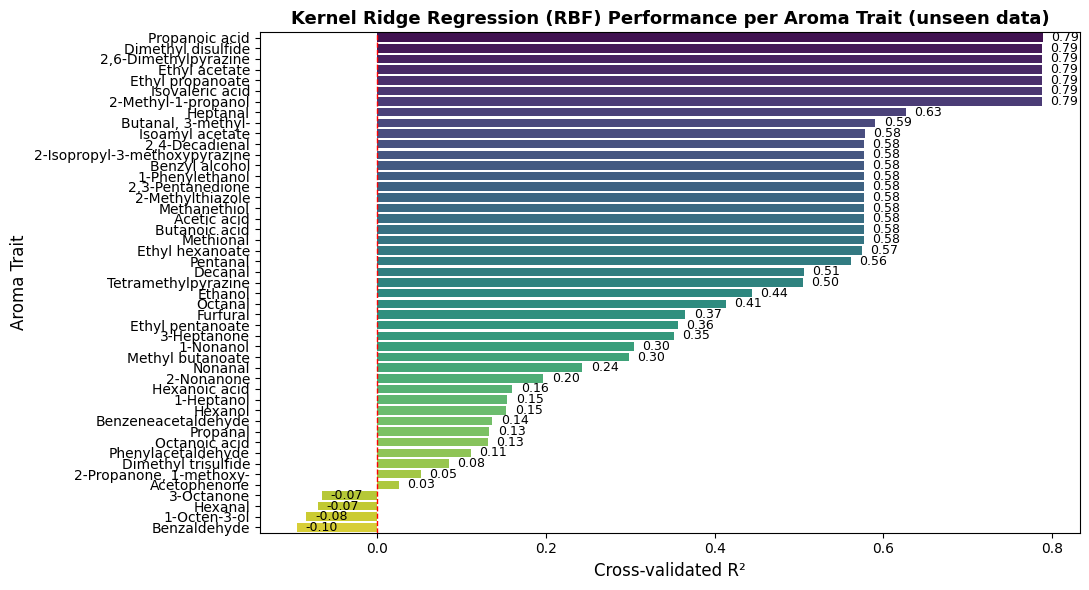

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  run_krr_models_gene_aroma

results_krr_outlier_removed = run_krr_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep2/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=6000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2",
    tag="unseen data"
)


# Linear Modeling of Sensory Principal Components Using GWAS-Derived Genetic Markers in Potato Varieties

In [ ]:


import importlib
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_linear_models_sensory

results_sensory = run_linear_models_sensory(
    gwas_file=all_gwas_df_sensory,
    merged_snp_df=merged_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=1000,
    prune_threshold=0.9,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2"
)




Loaded GWAS sensory data with shape: (783330, 4)
Columns: ['SNP', 'p_value', 'p_fdr', 'Trait']


# Nonlinear Modeling of Sensory Principal Components Using Kernel Ridge Regression (RBF Kernel)”

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_krr_sensory_pcs


# Define SNP thresholds to test
snp_thresholds = [100, 500, 1000, 2000, 4000, 6000]

mean_r2_results = {}

# Loop through each SNP threshold
for n in snp_thresholds:
    print(f"\n🔹 Running KRR–RBF sensory model with top_n_fallback = {n}")
    
    results_krr_fdr = run_krr_sensory_pcs(
        gwas_file=gwas_output_sensory,
        merged_snp_df=merged_snp_sensory,
        fdr_threshold=0.05,        # Keep consistent FDR filtering
        top_n_fallback=n,          # Vary SNP count
        prune_threshold=0.95,      # Keep LD pruning to prevent redundancy
        save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2"
    )
    
    # Calculate and store mean R² for this SNP threshold
    if not results_krr_fdr.empty:
        mean_r2 = results_krr_fdr["CV_Best_R2"].mean()
        mean_r2_results[n] = mean_r2
        print(f"→ Mean CV R² for top_n_fallback = {n}: {mean_r2:.4f}")
    else:
        mean_r2_results[n] = None
        print(" No results returned for this SNP threshold.")

# Convert to DataFrame
mean_r2_df = pd.DataFrame(list(mean_r2_results.items()), columns=["Top_N_SNPs", "Mean_CV_R2"])

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(mean_r2_df["Top_N_SNPs"], mean_r2_df["Mean_CV_R2"], marker="o", linestyle="-")
plt.xlabel("Number of Top SNPs Used")
plt.ylabel("Mean Cross-Validated R²")
plt.title("Effect of SNP Number on KRR–RBF Model Performance (Sensory PCs)")
plt.grid(True)
plt.tight_layout()

# Save plot
plot_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\krr_sensory_performance_vs_snps.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("\n SNP performance evaluation for KRR–RBF (Sensory PCs) completed.")
print(mean_r2_df)



🔹 Running KRR–RBF sensory model with top_n_fallback = 100


# Nonlinear Modeling of Sensory Principal Components Using SVR, Random Forest, and XGBoost

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_sensory_pcs




results_nonlinear_fdr10 = run_nonlinear_sensory_pcs(
    gwas_file=all_gwas_df_sensory,
    merged_snp_df=merged_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=4000, 
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)


TypeError: argument of type 'method' is not iterable

# Modeling After Outlier Removal

 Significant SNPs found: 341


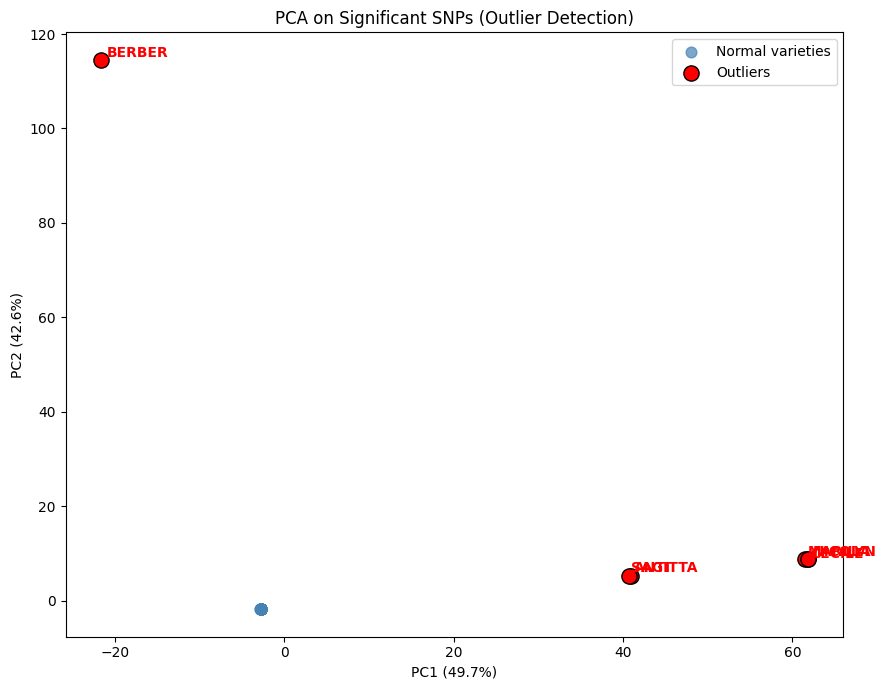

Detected PCA Outliers: ['ANTI', 'BERBER', 'CECILE', 'MARILYN', 'NICOLA', 'SAGITTA']
 Removed 6 outliers. Remaining: 88 samples.
Loaded GWAS sensory data with shape: (783330, 4)
Columns: ['SNP', 'p_value', 'p_fdr', 'Trait']
Loaded GWAS sensory data with shape: (783330, 4)
Columns: ['SNP', 'p_value', 'p_fdr', 'Trait']

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 195

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 2000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  Significant SNPs found: 146

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep2\genemarker_module.py:2302: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_sensory_PCs_plot_FDRfiltered.png


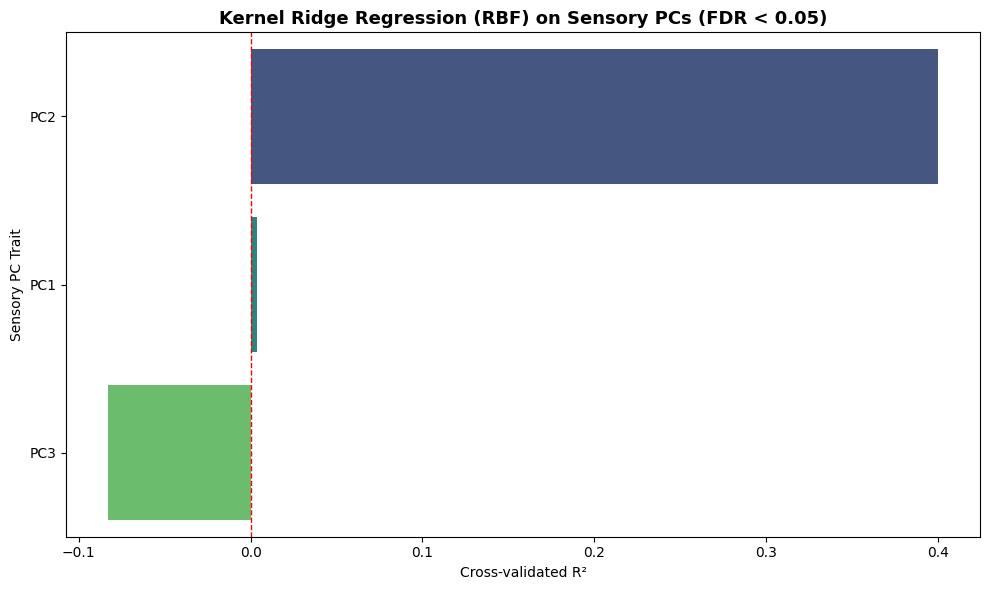


[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 195
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 2000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  Significant SNPs found: 146
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

 Nonlinear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered.csv
 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_FDRfiltered.png


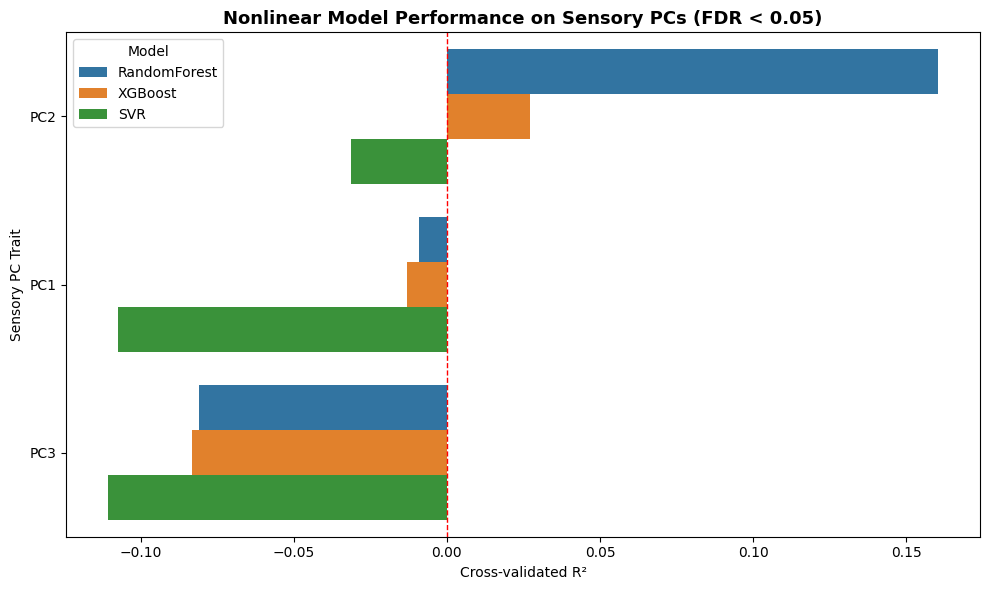

In [ ]:


# 1. Run PCA and detect outliers
results_pca = analyze_gwas_snps_pca(
    gwas_path=gwas_output_sensory,
    merged_snp_sensory=merged_snp_sensory
)

# 2. Extract outliers
pca_outliers = results_pca["pca_outliers"]
print(f"Detected PCA Outliers: {pca_outliers}")

# 3. Remove outliers
cleaned_snp_sensory = merged_snp_sensory.drop(
    index=[o for o in pca_outliers if o in merged_snp_sensory.index]
)
print(f" Removed {len(pca_outliers)} outliers. Remaining: {cleaned_snp_sensory.shape[0]} samples.")

results_linear_fdr05 = run_linear_models_sensory(
    gwas_file=gwas_output_sensory,
    merged_snp_df=cleaned_snp_sensory,
    fdr_threshold=0.1,       # can set to 0.1 if desired
    top_n_fallback=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)



results_sensory = run_linear_models_sensory(
    gwas_file=gwas_output_sensory,
    merged_snp_df=cleaned_snp_sensory,
    fdr_threshold=0.1,
    top_n_fallback=2000,
    prune_threshold=0.9,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)



results_krr_fdr10 = run_krr_sensory_pcs(
    gwas_file=gwas_output_sensory,
    merged_snp_df=cleaned_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=2000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
)

results_nonlinear_fdr10 = run_nonlinear_sensory_pcs(
    gwas_file=gwas_output_sensory,
    merged_snp_df= cleaned_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=2000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)


# Correlation Analysis Between Gene-Predicted Aroma Compounds and Sensory Principal Components


 Running KRR models for gene-predicted aroma compounds (outlier_removed)...

[KRR — outlier_removed] Trait: 1-Heptanol

[KRR — outlier_removed] Trait: 1-Nonanol

[KRR — outlier_removed] Trait: 1-Octen-3-ol

[KRR — outlier_removed] Trait: 1-Phenylethanol

[KRR — outlier_removed] Trait: 2,3-Pentanedione

[KRR — outlier_removed] Trait: 2,4-Decadienal

[KRR — outlier_removed] Trait: 2,6-Dimethylpyrazine

[KRR — outlier_removed] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — outlier_removed] Trait: 2-Methyl-1-propanol

[KRR — outlier_removed] Trait: 2-Methylthiazole

[KRR — outlier_removed] Trait: 2-Nonanone

[KRR — outlier_removed] Trait: 2-Propanone, 1-methoxy-

[KRR — outlier_removed] Trait: 3-Heptanone

[KRR — outlier_removed] Trait: 3-Octanone

[KRR — outlier_removed] Trait: Acetic acid

[KRR — outlier_removed] Trait: Acetophenone

[KRR — outlier_removed] Trait: Benzaldehyde

[KRR — outlier_removed] Trait: Benzeneacetaldehyde

[KRR — outlier_removed] Trait: Benzyl alcohol

[KRR — outlie

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:1907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  palette="viridis"


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\krr_models_plot_outlier_removed.png


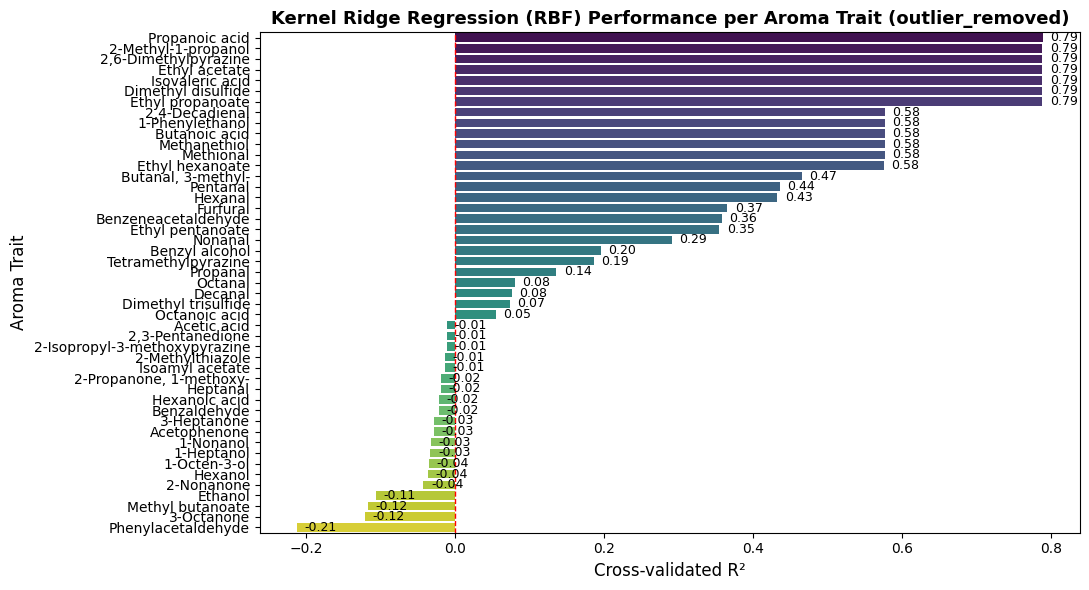


 High-performing traits (CV R² ≥ 0.5): 13
→ ['1-Phenylethanol', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Methyl-1-propanol', 'Butanoic acid', 'Dimethyl disulfide', 'Ethyl acetate', 'Ethyl hexanoate', 'Ethyl propanoate', 'Isovaleric acid', 'Methanethiol', 'Methional', 'Propanoic acid']

 Predictions DataFrame ready: (92, 13)
 Common samples between predictions (92) and sensory PCs (94): 92

 Correlation matrix saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep\gene_predicted_compound_sensory_corr_outlier_removed.csv


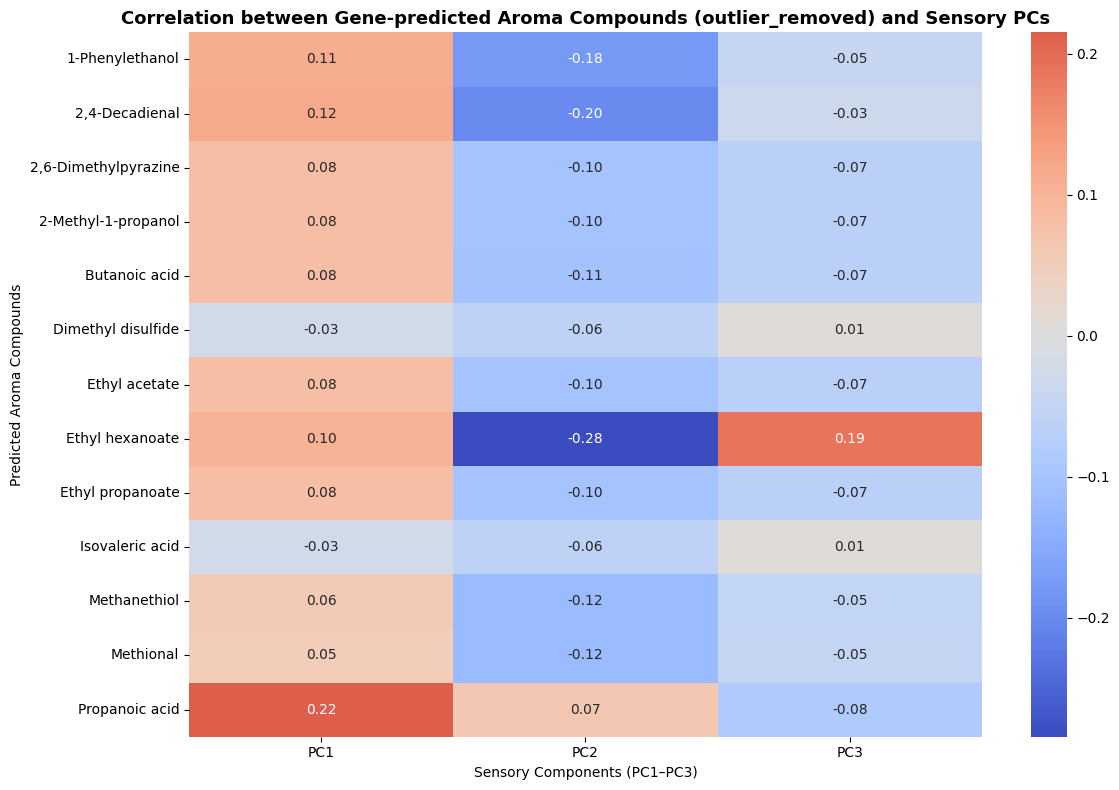


 Top correlations:


PC1  Propanoic acid          0.215025
PC3  Ethyl hexanoate         0.188432
PC1  2,4-Decadienal          0.118263
     1-Phenylethanol         0.112341
     Ethyl hexanoate         0.102005
     2-Methyl-1-propanol     0.083831
     2,6-Dimethylpyrazine    0.083831
     Ethyl propanoate        0.083831
     Ethyl acetate           0.083831
     Butanoic acid           0.083130
PC2  Propanoic acid          0.065242
PC1  Methanethiol            0.056316
     Methional               0.051879
PC3  Dimethyl disulfide      0.008138
     Isovaleric acid         0.008138
PC1  Dimethyl disulfide     -0.026421
     Isovaleric acid        -0.026421
PC3  2,4-Decadienal         -0.033342
     1-Phenylethanol        -0.045748
     Methional              -0.049819
dtype: float64

In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import correlate_gene_predictions_with_sensory_pcs




corr_matrix_outlier_removed = correlate_gene_predictions_with_sensory_pcs(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,  # 92 samples
    merged_snp_sensory=merged_snp_sensory,  # 94 samples (will auto-align)
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    top_n_snps=2000,
    prune_threshold=0.95,
    r2_threshold=0.5,
    tag="outlier_removed"
)


# Analysis of Gene Marker Effects for Top Correlated Aroma–Sensory Traits


 Found 11 high-correlation compounds (|r| ≥ 0.1):
→ ['Ethyl hexanoate', 'Propanoic acid', '2,4-Decadienal', '1-Phenylethanol', 'Methanethiol', 'Methional', 'Butanoic acid', 'Ethyl propanoate', '2-Methyl-1-propanol', '2,6-Dimethylpyrazine', 'Ethyl acetate']

 Analyzing 1-Phenylethanol (20 SNPs)...


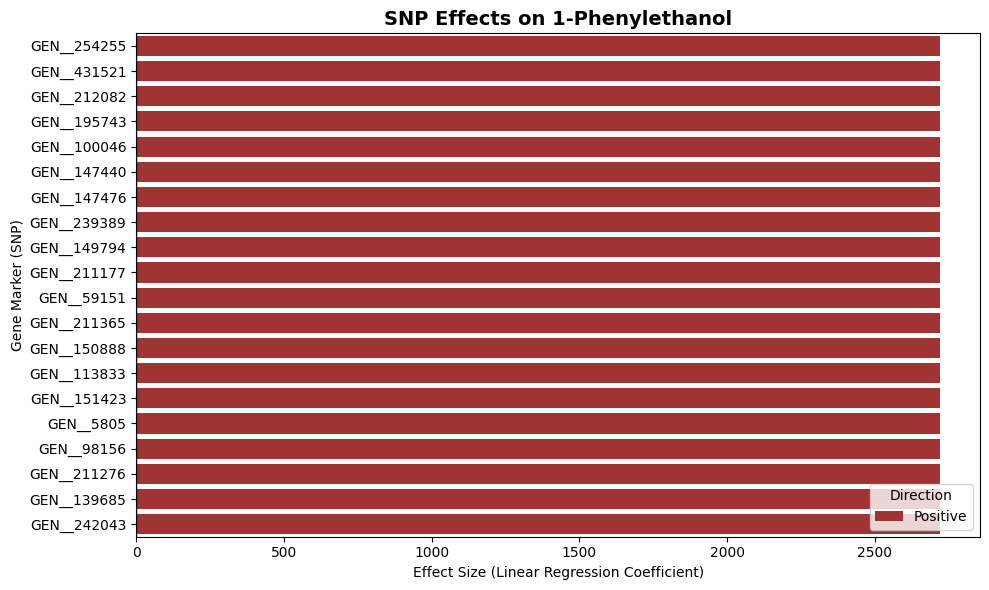


 Analyzing 2,4-Decadienal (20 SNPs)...


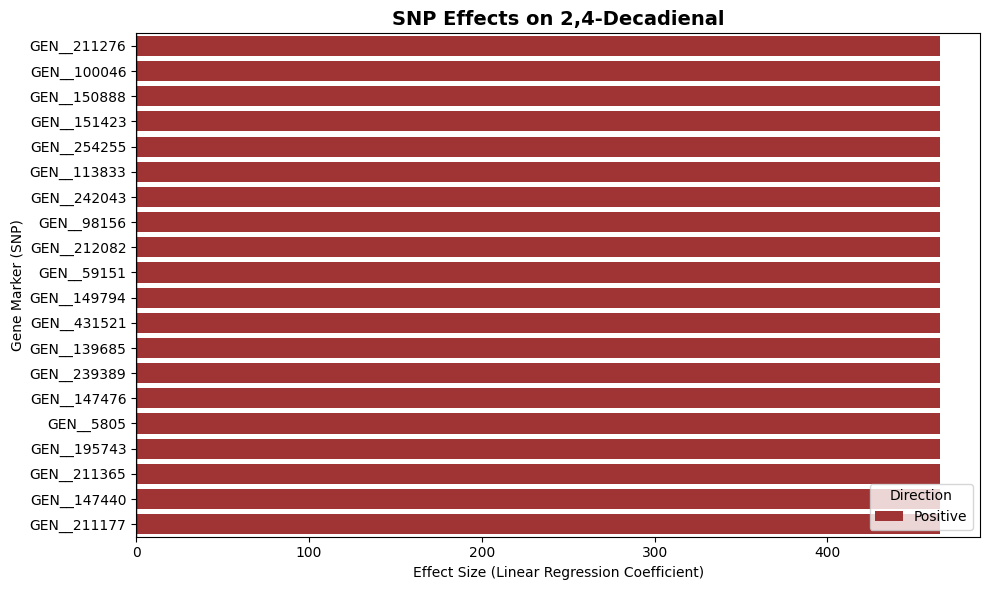


 Analyzing 2,6-Dimethylpyrazine (20 SNPs)...


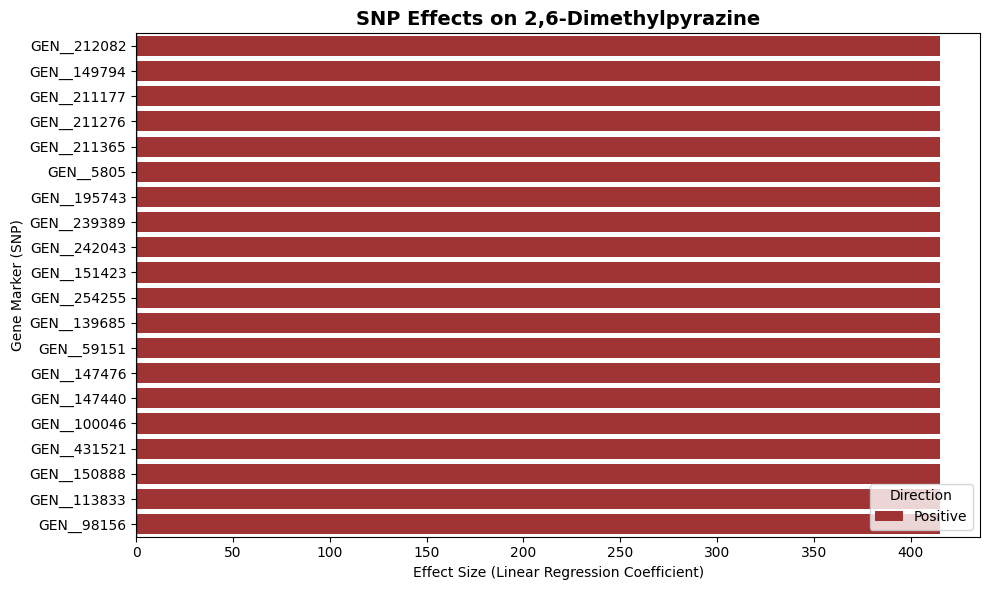


 Analyzing 2-Methyl-1-propanol (20 SNPs)...


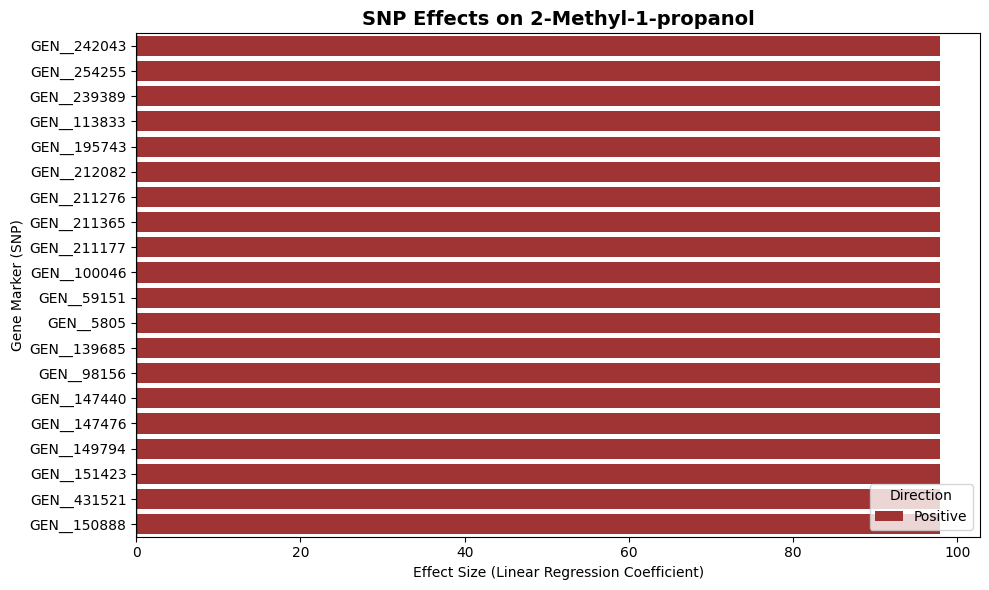


 Analyzing Butanoic acid (20 SNPs)...


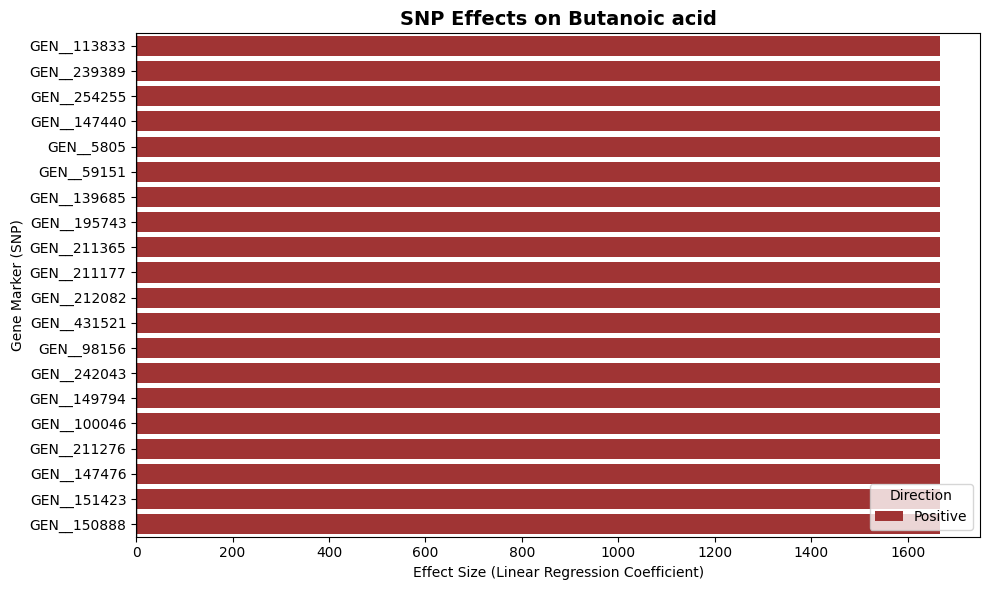


 Analyzing Ethyl acetate (20 SNPs)...


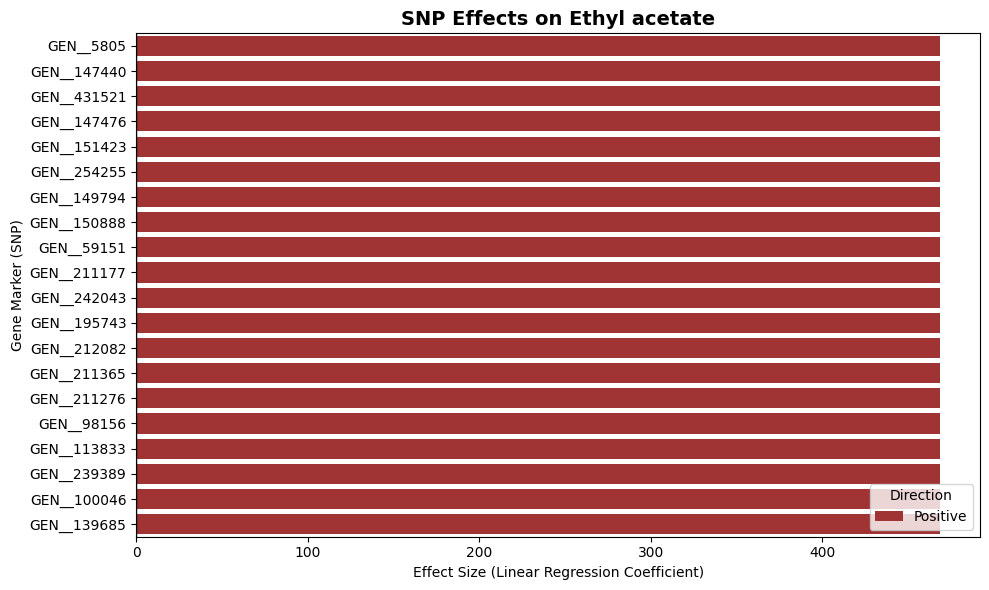


 Analyzing Ethyl hexanoate (20 SNPs)...


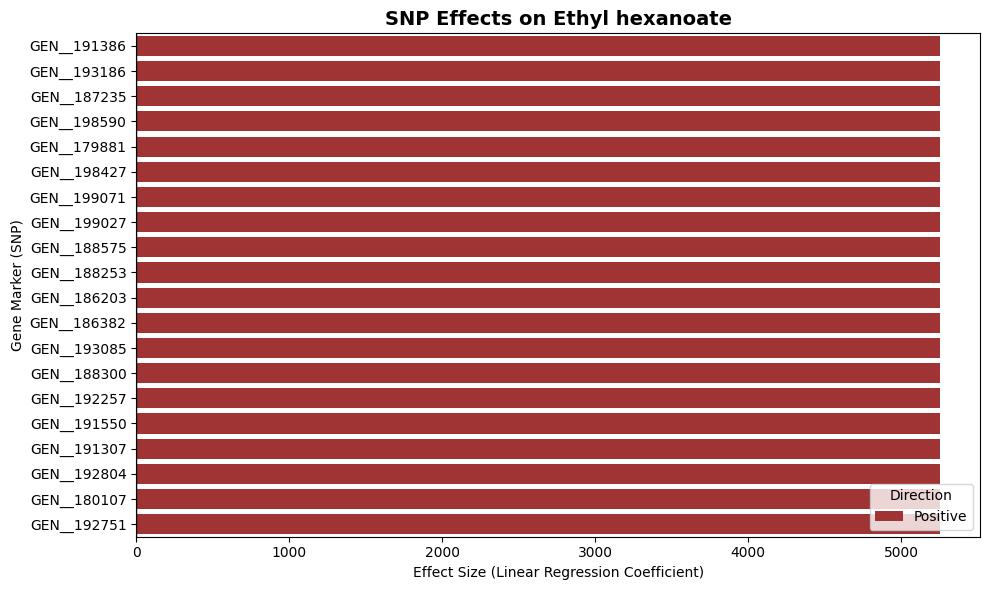


 Analyzing Ethyl propanoate (20 SNPs)...


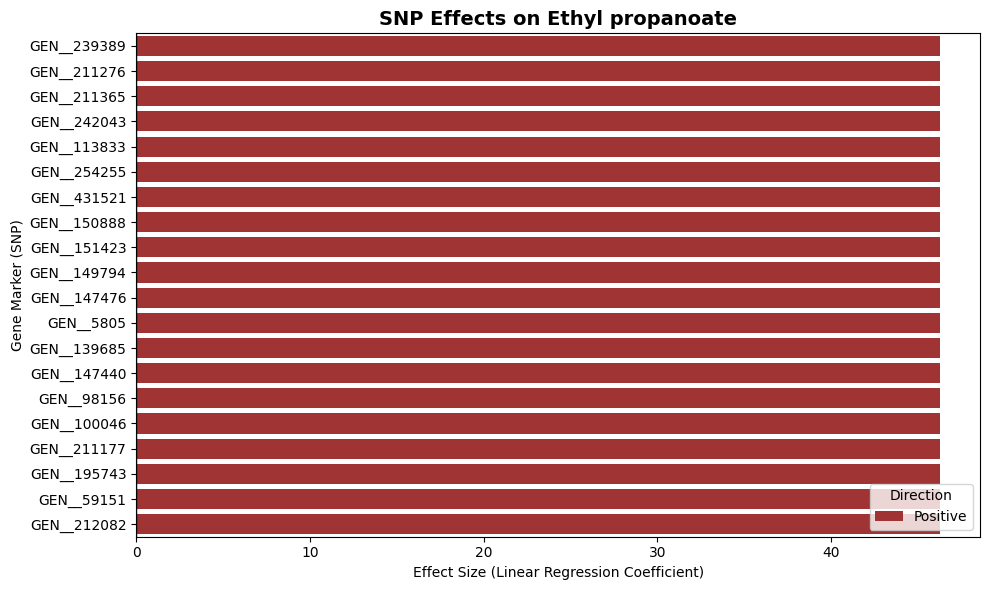


 Analyzing Methanethiol (20 SNPs)...


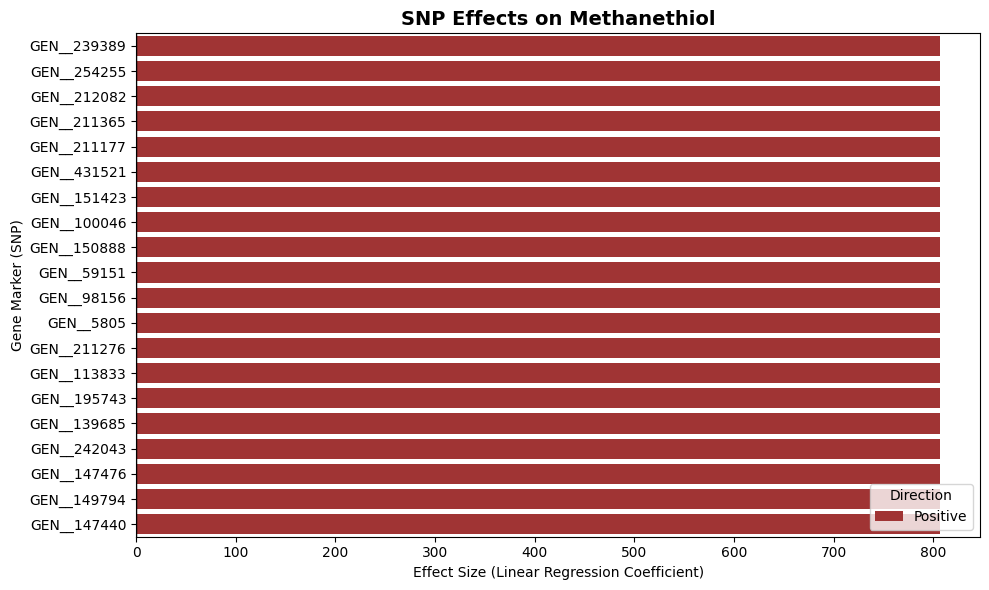


 Analyzing Methional (20 SNPs)...


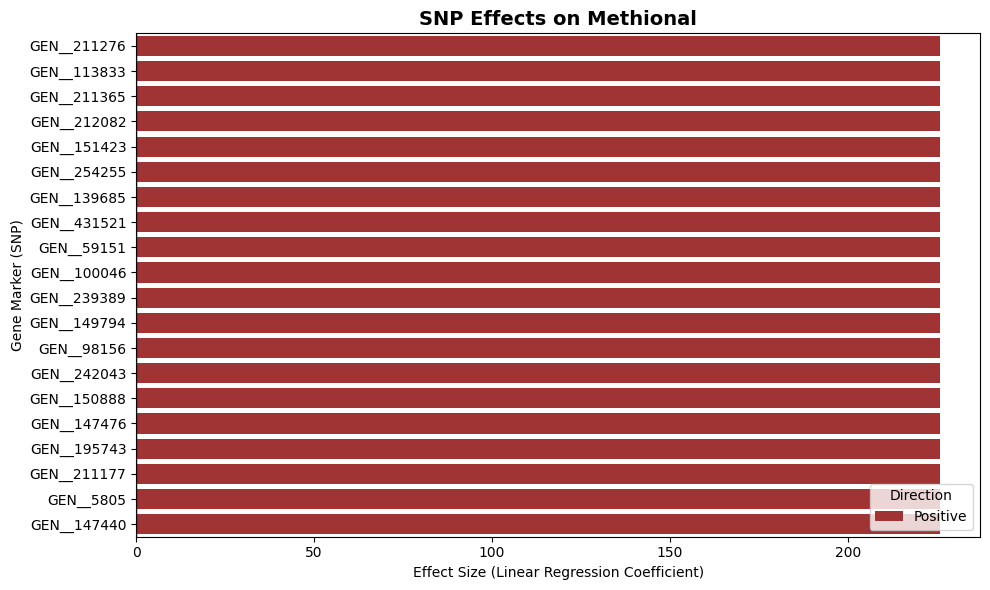


 Analyzing Propanoic acid (20 SNPs)...


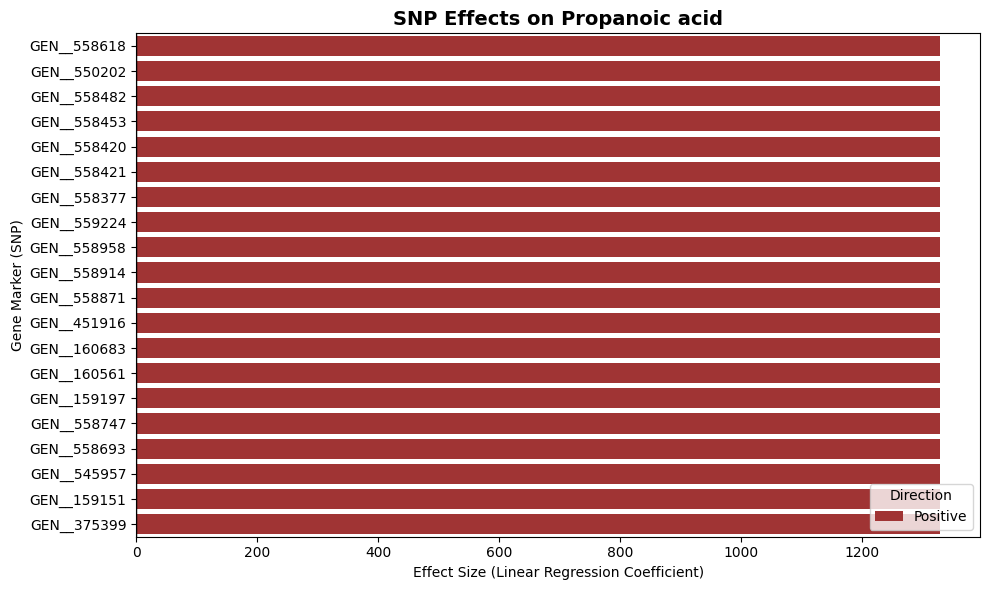


 Finished analyzing SNP effects for high-correlation traits.


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  analyze_marker_effects_for_top_correlated_traits


effects_summary = analyze_marker_effects_for_top_correlated_traits(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    df_aroma=cleaned_data_gene_aroma,
    corr_matrix=corr_matrix_outlier_removed,
    corr_threshold=0.1,
    top_snps_per_trait=20,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)


In [ ]:
# import importlib
# import yaml
# import genemarker_module
# importlib.reload(genemarker_module)
# from genemarker_module import reconstruct_sensory_traits_from_pca


# sensory_reconstructed_df = reconstruct_sensory_traits_from_pca(
#     projection_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_projection.csv",
#     loadings_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_pca_loadings.csv",
#     save_path=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1',
#     n_components=3
# )


 Reconstructed sensory traits using 3 PCs:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits → C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv


# PLSR Analysis Between High-Predictive Gene-Based Compounds and Reconstructed Sensory Attributes


[KRR — default] Trait: 1-Heptanol


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



[KRR — default] Trait: 1-Nonanol

[KRR — default] Trait: 1-Octen-3-ol

[KRR — default] Trait: 1-Phenylethanol

[KRR — default] Trait: 2,3-Pentanedione

[KRR — default] Trait: 2,4-Decadienal

[KRR — default] Trait: 2,6-Dimethylpyrazine

[KRR — default] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — default] Trait: 2-Methyl-1-propanol

[KRR — default] Trait: 2-Methylthiazole

[KRR — default] Trait: 2-Nonanone

[KRR — default] Trait: 2-Propanone, 1-methoxy-

[KRR — default] Trait: 3-Heptanone

[KRR — default] Trait: 3-Octanone

[KRR — default] Trait: Acetic acid

[KRR — default] Trait: Acetophenone

[KRR — default] Trait: Benzaldehyde

[KRR — default] Trait: Benzeneacetaldehyde

[KRR — default] Trait: Benzyl alcohol

[KRR — default] Trait: Butanal, 3-methyl-

[KRR — default] Trait: Butanoic acid

[KRR — default] Trait: Decanal

[KRR — default] Trait: Dimethyl disulfide

[KRR — default] Trait: Dimethyl trisulfide

[KRR — default] Trait: Ethanol

[KRR — default] Trait: Ethyl acetate

[KRR — 

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:1913: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\krr_models_plot_default.png


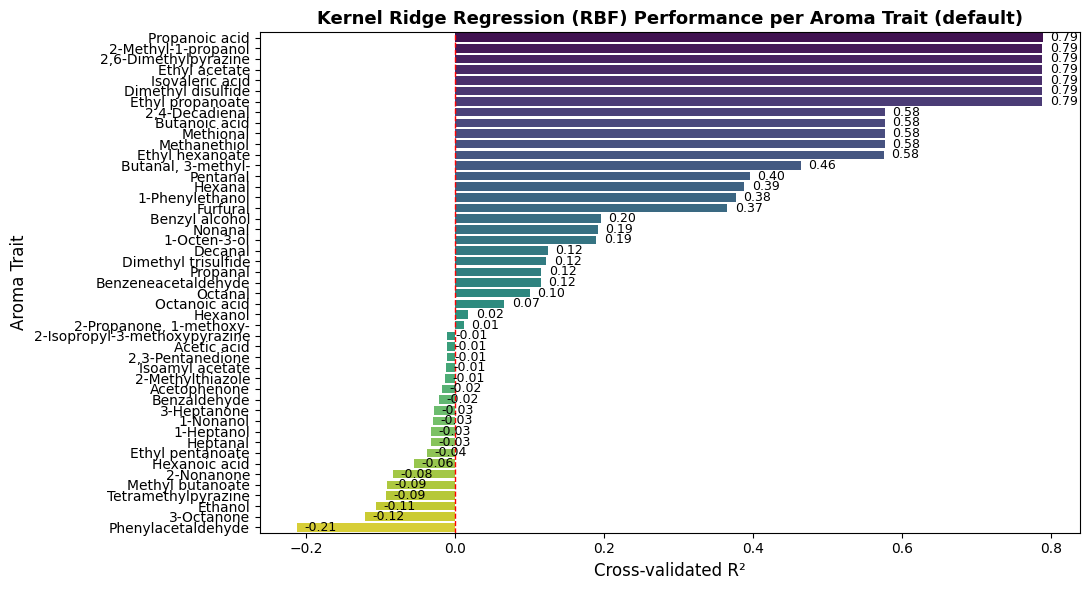

 Common varieties found: 84
 Using 12 high-predictive compounds for PLS
 Fitted PLS model with 5 components

 Correlation between PLS components and sensory attributes:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
PLS1,-0.03,-0.05,0.08,-0.10,-0.15,-0.19,-0.03,0.03,-0.04,-0.12,-0.18,0.20,-0.07,-0.15,0.17,0.02,-0.17,-0.23,0.23,0.05
PLS2,-0.08,-0.11,0.04,-0.16,-0.03,-0.10,0.03,0.03,-0.11,-0.18,-0.10,0.14,-0.12,0.00,0.26,-0.10,-0.03,-0.18,0.29,0.00
PLS3,0.17,0.16,0.17,0.14,-0.16,-0.15,0.11,0.16,0.16,0.13,-0.16,0.14,0.15,-0.12,0.06,0.17,-0.12,-0.11,0.04,0.18
PLS4,-0.07,-0.08,-0.02,-0.10,-0.03,-0.06,-0.06,-0.04,-0.08,-0.11,-0.05,0.06,-0.09,-0.05,0.06,-0.04,-0.06,-0.09,0.10,-0.03
PLS5,0.01,0.01,0.01,0.01,-0.02,-0.02,-0.01,0.00,0.01,0.01,-0.01,0.01,0.01,-0.03,-0.02,0.02,-0.02,-0.01,-0.01,0.01


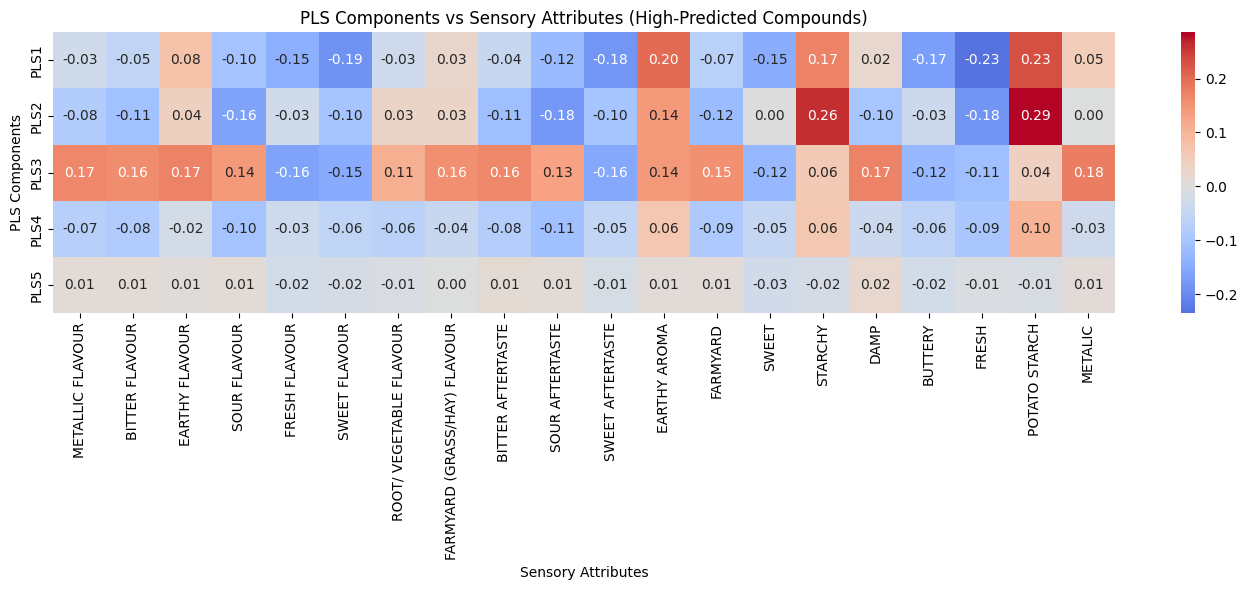

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2794: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.title(f"Top 15 Compound Contributors to {comp}")


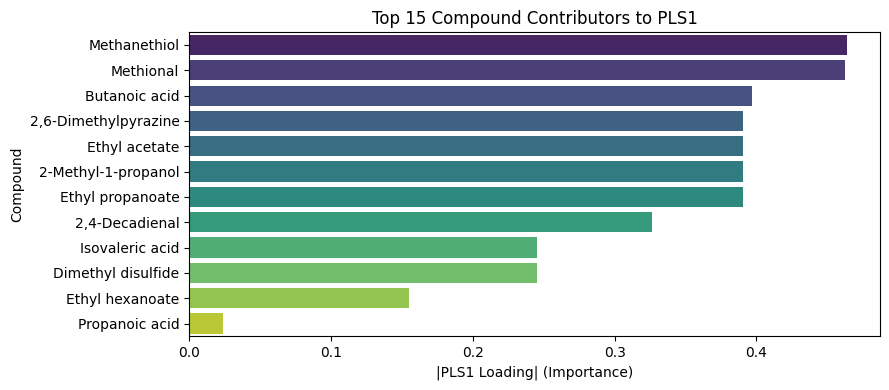

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2794: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.title(f"Top 15 Compound Contributors to {comp}")


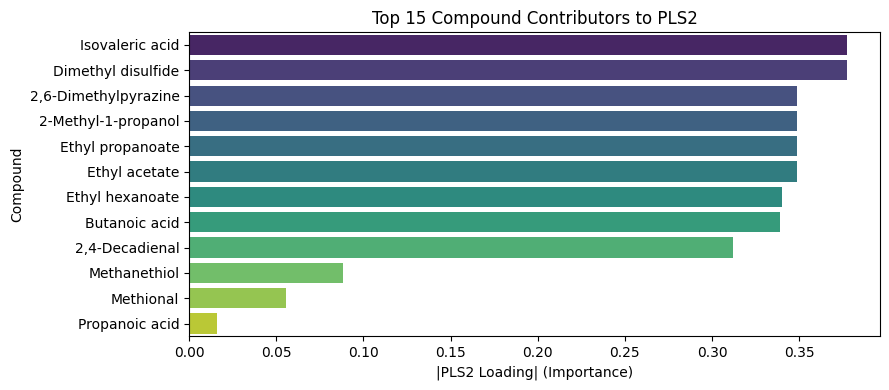

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2794: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.title(f"Top 15 Compound Contributors to {comp}")


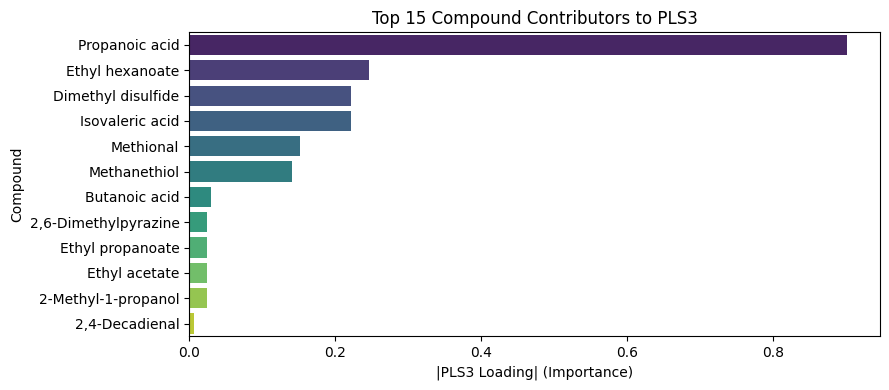

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2794: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.title(f"Top 15 Compound Contributors to {comp}")


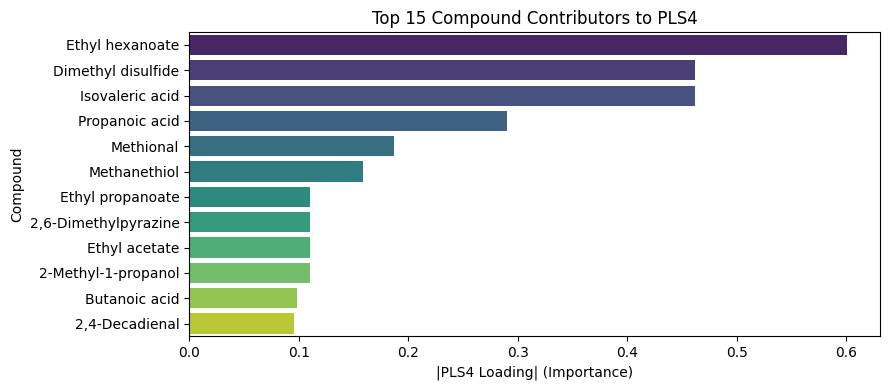

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2794: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.title(f"Top 15 Compound Contributors to {comp}")


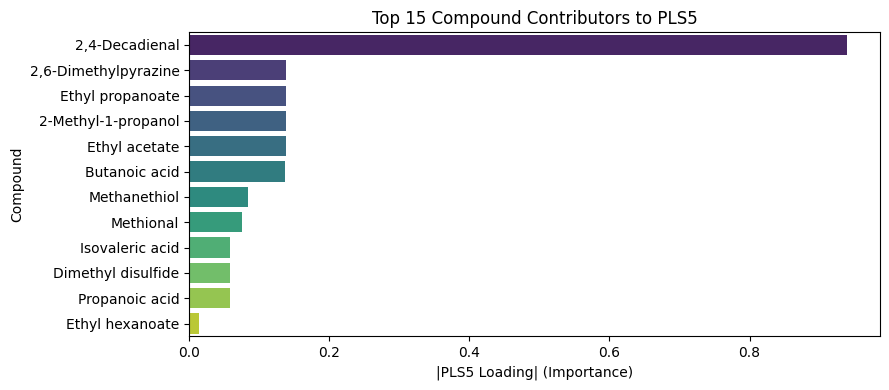


 Flavor alignment per PLS axis:
  PLS1: aligned with FRESH (negative)
  PLS2: aligned with POTATO STARCH (positive)
  PLS3: aligned with METALIC (positive)
  PLS4: aligned with SOUR AFTERTASTE (negative)
  PLS5: aligned with SWEET (negative)

 Correlation and loadings files saved successfully:
   → C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_high_predicted_compound_sensory_correlations.csv
   → C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_high_predicted_compound_loadings.csv


In [ ]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_plsr_gene_predicted_vs_sensory,run_krr_models_gene_aroma



high_r2_traits = results_krr_outlier_removed.query("CV_Best_R2 >= 0.5")["Trait"].tolist()
results_krr, predictions = run_krr_models_gene_aroma(
        gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
        snp_df=cleaned_data_gene_aroma,
        top_n_snps=1000,
        prune_threshold=0.95,
        save_dir=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1',
        tag='default'
    )


pls_results = run_plsr_gene_predicted_vs_sensory(
    predictions=predictions,
    sensory_reconstructed_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv",
    high_r2_traits=high_r2_traits,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship",
    n_components=5
)


# PLSR Analysis Between Gene-Predicted Aroma Compounds and Sensory Attribute biplot

 Common varieties found: 84
X_scaled shape: (84, 12), Y_scaled shape: (84, 20)
 PLS model fitted successfully!


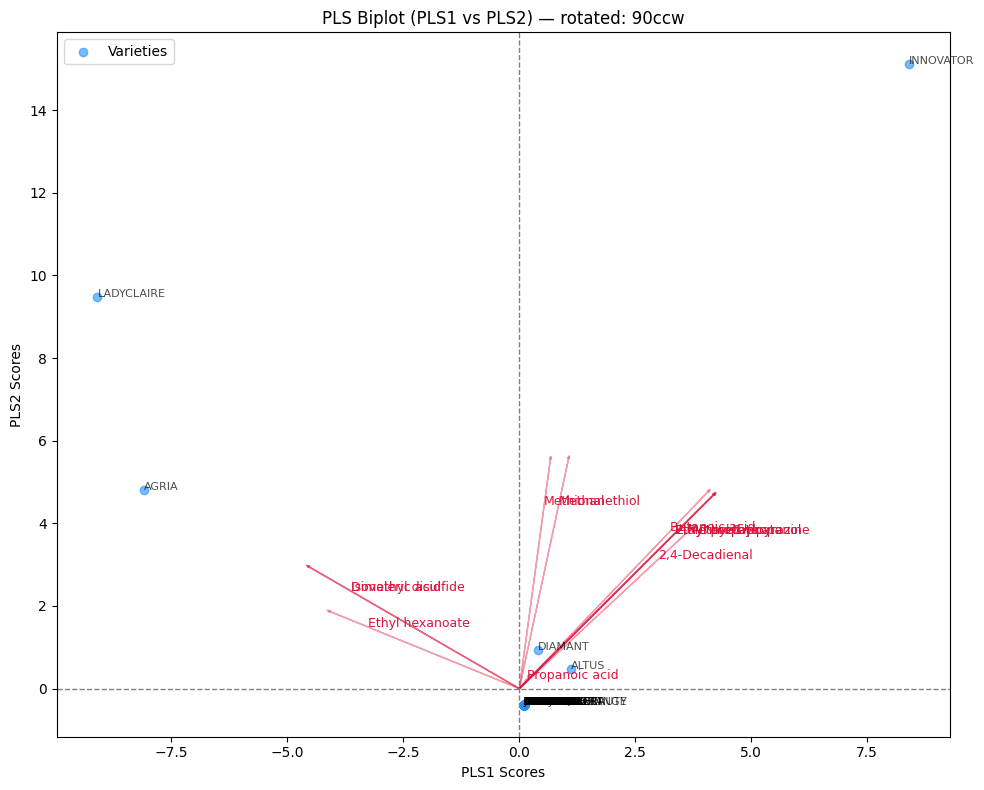

In [ ]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  prepare_plsr_data, plot_plsr_biplot


#Prepare data and fit PLS

sensory_reconstructed_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\sensory_reconstructed_traits.csv"

#  Make sure 'predictions' and 'high_r2_traits' already exist in memory
X, Y, X_scaled, Y_scaled = prepare_plsr_data(predictions, high_r2_traits, sensory_reconstructed_path)

# Fit PLS model
pls = PLSRegression(n_components=5)
pls.fit(X_scaled, Y_scaled)
print(" PLS model fitted successfully!")


# Visualize PLS biplot

plot_plsr_biplot(
    pls_model=pls,
    X_scaled=pd.DataFrame(X_scaled, index=X.index, columns=X.columns),
    pc1=1,
    pc2=2,
    rotate='90ccw',
    top_n_loadings=15,
    scale_arrows=12
)
